In [140]:
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, roc_auc_score)

In [141]:
# Load data  
df = pd.read_csv("unicef_malawi.csv")
df.head()

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
0,1.0,2.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,NO,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,5.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,YES,NO
1,1.0,3.0,1.0,1.0,5.0,YES,ECE,NaN,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,YES
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
3,1.0,8.0,2.0,2.0,13.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO
4,1.0,10.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,8.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13162 non-null  float64
 1   HH2         13162 non-null  float64
 2   LN          13162 non-null  float64
 3   FS4         13162 non-null  float64
 4   CB3         13059 non-null  float64
 5   CB4         13059 non-null  object 
 6   CB5A        12203 non-null  object 
 7   CB5B        11575 non-null  object 
 8   CB7         12203 non-null  object 
 9   CB11        13059 non-null  object 
 10  CL3         4159 non-null   float64
 11  CL13        11092 non-null  object 
 12  FCD2A       11264 non-null  object 
 13  FCD2B       11264 non-null  object 
 14  FCD2C       11264 non-null  object 
 15  FCD2D       11264 non-null  object 
 16  FCD2E       11264 non-null  object 
 17  FCD2F       11264 non-null  object 
 18  FCD2G       11264 non-null  object 
 19  FCD2H       11264 non-nul

### 0. First tidy up NaNs, because couldn't split the data with NaNs
strategy: checking all the data inputs and ratio of NaN values in the dataset

In [143]:
print(f"Total NaNs: {df.isnull().sum().sum()}")
print(f"Rows with any NaN: {df.isnull().any(axis=1).sum()}")
print(f"Total NO \"RESPONSE\": {(df == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df[df == "NO RESPONSE"].any(axis=1).sum()}")


Total NaNs: 71374
Rows with any NaN: 12458
Total NO "RESPONSE": 1293
Rows with any "NO RESPONSE": 1121


In [144]:
df[df.isin(['NO RESPONSE']).any(axis=1)]

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
16,2.0,4.0,2.0,2.0,10.0,YES,PRIMARY,CLASS/YEAR/GRADE 4,YES,NO,...,NO,YES,PIPED WATER: PIPED TO YARD / PLOT,NaN,NaN,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,NaN
31,3.0,17.0,2.0,2.0,8.0,YES,PRIMARY,CLASS/YEAR/GRADE 3,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,20.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,NO,NO
39,4.0,5.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,DUG WELL: PROTECTED WELL,ELSEWHERE,20.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NaN
67,6.0,14.0,2.0,2.0,7.0,YES,PRIMARY,CLASS/YEAR/GRADE 1,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,25.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13026,1101.0,4.0,1.0,1.0,14.0,YES,PRIMARY,CLASS/YEAR/GRADE 5,YES,NO RESPONSE,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,90.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NO
13100,1107.0,4.0,2.0,2.0,5.0,YES,ECE,NaN,YES,NO,...,YES,YES,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,10.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NaN
13124,1109.0,1.0,1.0,1.0,10.0,YES,PRIMARY,CLASS/YEAR/GRADE 4,YES,NO,...,NO,NO,TUBE WELL / BOREHOLE,ELSEWHERE,150.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NaN
13127,1109.0,7.0,2.0,2.0,5.0,YES,ECE,NaN,YES,NO,...,NO,NO,DUG WELL: UNPROTECTED WELL,NO RESPONSE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,YES


_Significantly more NaNs than expected!_\
_Not only do we have a couple of columns with a high number of NaNs (HW5,FCD5, CL3(!!)), but also 12458 / 13162 rows have at least 1 missing vaulue -> can't just delete rows with missing values as we'd have a fraction of the dataset left._

In [145]:
df = df.fillna('NO RESPONSE')

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13162 non-null  float64
 1   HH2         13162 non-null  float64
 2   LN          13162 non-null  float64
 3   FS4         13162 non-null  float64
 4   CB3         13162 non-null  object 
 5   CB4         13162 non-null  object 
 6   CB5A        13162 non-null  object 
 7   CB5B        13162 non-null  object 
 8   CB7         13162 non-null  object 
 9   CB11        13162 non-null  object 
 10  CL3         13162 non-null  object 
 11  CL13        13162 non-null  object 
 12  FCD2A       13162 non-null  object 
 13  FCD2B       13162 non-null  object 
 14  FCD2C       13162 non-null  object 
 15  FCD2D       13162 non-null  object 
 16  FCD2E       13162 non-null  object 
 17  FCD2F       13162 non-null  object 
 18  FCD2G       13162 non-null  object 
 19  FCD2H       13162 non-nul

Filled with "NO RESPONSE" globally to split into test/training. More data investigation after the split

In [147]:
X = df.drop(columns=['FCF26']) 
y = df['FCF26']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=8, ## fixing the state for reproducibility
    stratify=y      ## to guarantee balanced split of data
)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

See if any of the missing information is correlated

<Axes: >

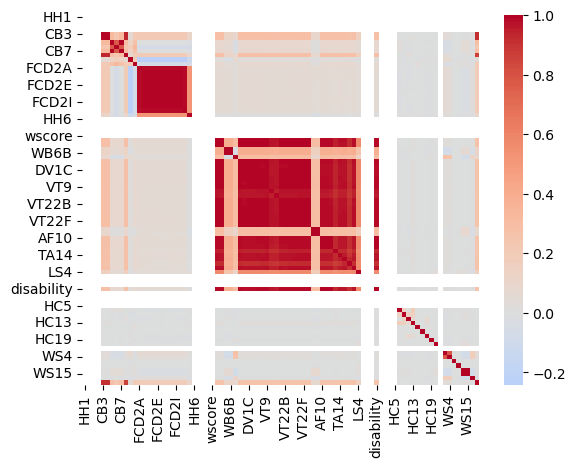

In [148]:
no_response_matrix = (df_train == 'NO RESPONSE').astype(int)
no_response_corr = no_response_matrix.corr()
sns.heatmap(no_response_corr, cmap='coolwarm', center=0, annot=False)

101 missing FCF26 responses - dropping

In [149]:
df_train = df_train[df_train['FCF26'] != 'NO RESPONSE']
df_test = df_test[df_test['FCF26'] != 'NO RESPONSE']

#### 0.1 checking if there is any reason for the missing data (Child Labour subset)

In [150]:
cols = ['CL2','CL3', 'CL12', 'CL13', 'FCF26']
df_train[df_train['CL3'].isin(['NO RESPONSE'])][cols]

,CL2,CL3,CL12,CL13,FCF26
773,False,NO RESPONSE,True,1.0,A FEW TIMES A YEAR
2464,False,NO RESPONSE,True,4.0,MONTHLY
5113,False,NO RESPONSE,True,0.0,A FEW TIMES A YEAR
10868,False,NO RESPONSE,True,0.0,A FEW TIMES A YEAR
7909,False,NO RESPONSE,True,0.0,NEVER
...,...,...,...,...,...
6910,False,NO RESPONSE,False,NO RESPONSE,NEVER
295,False,NO RESPONSE,True,3.0,MONTHLY
2558,False,NO RESPONSE,True,3.0,A FEW TIMES A YEAR
6331,False,NO RESPONSE,True,30.0,NEVER


In [151]:
## check how False / True translates to CL2
df_train[df_train['CL3'] == 'NO RESPONSE']['CL2'].value_counts(normalize=True)

CL2
False    1.0
Name: proportion, dtype: float64

_Conclusion: whereever CL2 is False (Child Labour = False), there's a missing CL3 value. This means, all CL3 NaNs can be made 0, as the child is NOT working = 0 working hours._

In [152]:
df_train.CL3.unique()

array(['NO RESPONSE', 3.0, 1.0, 20.0, 0.0, 28.0, 6.0, 2.0, 5.0, 4.0, 12.0,
       10.0, 14.0, 13.0, 7.0, 36.0, 9.0, 11.0, 8.0, 40.0, 23.0, 30.0,
       15.0, 21.0, 42.0, 18.0, 63.0, 77.0, 60.0, 27.0, 26.0, 24.0, 56.0,
       16.0, 25.0, 35.0, 43.0, 22.0, 32.0, 49.0, 70.0, 66.0, 45.0, 55.0,
       72.0, 17.0], dtype=object)

In [153]:
df_train['CL3'] = df_train['CL3'].replace('NO RESPONSE', 0.0)
df_test['CL3'] = df_test['CL3'].replace('NO RESPONSE', 0.0)

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_56405/2669409082.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['CL3'] = df_train['CL3'].replace('NO RESPONSE', 0.0)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_56405/2669409082.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['CL3'] = df_test['CL3'].replace('NO RESPONSE', 0.0)


In [154]:
df_train[df_train['CL13'] == 'NO RESPONSE']['CL12'].value_counts(normalize=True)

CL12
False    0.998724
True     0.001276
Name: proportion, dtype: float64

In [155]:
df_train.CL13.unique()

array(['1.0', '6.0', '4.0', '16.0', '0.0', '25.0', '5.0', 'NO RESPONSE',
       '20.0', '14.0', '2.0', '8.0', '3.0', '10.0', '30.0', '7.0', '11.0',
       '15.0', '17.0', '48.0', '9.0', '44.0', '13.0', '23.0', '12.0',
       '39.0', '22.0', '40.0', '35.0', '42.0', '18.0', '21.0', '28.0',
       '19.0', '24.0', '43.0', '60.0', '50.0', '45.0', '51.0', '26.0',
       '34.0', '29.0', '33.0', '32.0', '66.0', '54.0', '31.0', '56.0',
       '72.0', '55.0'], dtype=object)

_99.8% of data for CL13 and CL12 follow the same rule -> make CL13 0.0_

In [156]:
df_train['CL13'] = df_train['CL13'].replace('NO RESPONSE', 0.0)
df_test['CL13'] = df_test['CL13'].replace('NO RESPONSE', 0.0)

In [157]:
print(f"Total NO \"RESPONSE\": {(df_train == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df_train[df_train == "NO RESPONSE"].any(axis=1).sum()}")

Total NO "RESPONSE": 46369
Rows with any "NO RESPONSE": 8776


In [158]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD5       3933
HW5        2777
MA3        2376
MA2        2352
WB14       2303
           ... 
MSTATUS       0
CSURV         0
CDEAD         0
CL2           0
FCF26         0
Length: 87, dtype: int64

FCD5. _Do you believe that in order to bring up, raise, or educate a child properly, the child needs to be physically punished?_\
checing correlation with other FCD columns

FCD2A-K are different types of physical punishment methods

In [159]:
fcd_cols = ['FCD5','FCD2A','FCD2B', 'FCD2C',
'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K']
df_train[df_train['FCD5'] == 'NO RESPONSE'][fcd_cols + ['FCF26']]

,FCD5,FCD2A,FCD2B,FCD2C,FCD2D,FCD2E,FCD2F,FCD2G,FCD2H,FCD2I,FCD2J,FCD2K,FCF26
773,NO RESPONSE,NO,YES,NO,YES,YES,NO,NO,NO,NO,NO,NO,A FEW TIMES A YEAR
2464,NO RESPONSE,NO,YES,NO,YES,YES,NO,NO,YES,NO,NO,NO,MONTHLY
11506,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,WEEKLY
7909,NO RESPONSE,YES,YES,NO,YES,YES,NO,NO,NO,NO,NO,NO,NEVER
9934,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
2558,NO RESPONSE,YES,YES,NO,YES,YES,YES,YES,YES,NO,NO,NO,A FEW TIMES A YEAR
5304,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR
6331,NO RESPONSE,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,NO,NEVER


In [160]:
df_train[df_train['FCD2K'] == 'NO RESPONSE'][fcd_cols].value_counts(normalize=True)

FCD5         FCD2A        FCD2B        FCD2C        FCD2D        FCD2E        FCD2F        FCD2G        FCD2H        FCD2I        FCD2J        FCD2K      
NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE    0.984962
NO           NO           NO           NO           NO           NO           NO           NO           NO           NO           NO           NO RESPONSE    0.000684
NO RESPONSE  NO           YES          NO           NO           NO           NO           NO           NO           NO           NO           NO RESPONSE    0.000684
YES          NO           YES          NO           YES          YES          NO           NO           YES          YES          NO           NO RESPONSE    0.000684
NO RESPONSE  YES          YES          YES          YES          NO           YES          NO           YES          NO           NO           NO RESPONSE    0.000684
          

<Axes: >

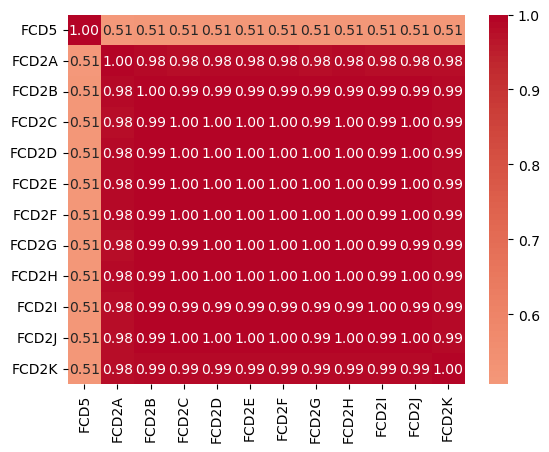

In [161]:
fcd_no_resp = (df_train[fcd_cols] == 'NO RESPONSE').astype(int)
sns.heatmap(fcd_no_resp.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f')

_Conclusion: If there is missing data for one Physical punishment type (FCD2) column, it is missing in almost all the other FCD2X ones -> it looks like an intentional skip, but we can't quite tell if it's missed because a person doesn't want to disclose what kind of punishment they use OR they don't agree with punishment. First step: if FCD2 columns are ALL "NO", make FCD5 "NO RESPONSE" a "NO" too. If there's any "YES" make it a "YES"._

In [162]:
fcd2_cols = ['FCD2A','FCD2B', 'FCD2C',
'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K']

for df in [df_train, df_test]:
    mask = df['FCD5'].isin(['NO RESPONSE', 'DK / NO OPINION'])
    
    any_yes = df.loc[mask, fcd2_cols].isin(['YES']).any(axis=1)
    df.loc[mask & any_yes, 'FCD5'] = 'YES'
    
    all_no = (df.loc[mask, fcd2_cols] == 'NO').all(axis=1)
    df.loc[mask & all_no, 'FCD5'] = 'NO'

In [163]:
df_train['FCD5'].value_counts()

FCD5
NO             5440
YES            3544
NO RESPONSE    1444
Name: count, dtype: int64

In [164]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

HW5        2777
MA3        2376
MA2        2352
WB14       2303
FCD2A      1479
           ... 
MSTATUS       0
CSURV         0
CDEAD         0
CL2           0
FCF26         0
Length: 87, dtype: int64

HW5. _Do you have any soap or detergent or ash/mud/sand in your house for washing hands?_

MA2. How old is your (husband/partner)?
Probe: How old was your (husband/partner) on his last birthday?

MA3. Besides yourself, does your (husband/partner) have any other wives or partners or does he live with other women as if married?

In [165]:
top_NaNs_cols = ['HW5','MA3', 'MA2']
df_train[df_train['MA2'] == 'NO RESPONSE'][top_NaNs_cols + ['FCF26']]

,HW5,MA3,MA2,FCF26
11506,NO,NO RESPONSE,NO RESPONSE,WEEKLY
7909,YES,NO RESPONSE,NO RESPONSE,NEVER
9934,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
12931,YES,NO RESPONSE,NO RESPONSE,WEEKLY
10140,NO,NO RESPONSE,NO RESPONSE,NEVER
...,...,...,...,...
8465,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
10276,YES,NO RESPONSE,NO RESPONSE,MONTHLY
8734,YES,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR
8307,NO,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR


In [166]:
df_train[df_train['MA3'] == 'NO RESPONSE']['MSTATUS'].value_counts(normalize=True)

MSTATUS
Formerly married/in union     0.843013
Never married/in union        0.088384
Currently married/in union    0.068603
Name: proportion, dtype: float64

In [167]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

married_mask_train = df_train['MSTATUS'] == 'Currently married/in union'
married_mask_test = df_test['MSTATUS'] == 'Currently married/in union'

df_train.loc[married_mask_train, ['MA2', 'MA3']] = imputer.fit_transform(
    df_train.loc[married_mask_train, ['MA2', 'MA3']]
)
df_test.loc[married_mask_test, ['MA2', 'MA3']] = imputer.transform(
    df_test.loc[married_mask_test, ['MA2', 'MA3']]
)

In [168]:
df_train['MA2'].value_counts(normalize=True)

MA2
NO RESPONSE    0.212217
40.0           0.053414
35.0           0.039317
45.0           0.034522
37.0           0.032892
                 ...   
85.0           0.000096
13.0           0.000096
12.0           0.000096
11.0           0.000096
16.0           0.000096
Name: proportion, Length: 70, dtype: float64

In [169]:
df_train.loc[df_train['MA2'] == 'NO RESPONSE', 'MA2'] = 0.0
df_train.loc[df_train['MA3'] == 'NO RESPONSE', 'MA3'] = 'NOT MARRIED'
df_test.loc[df_test['MA2'] == 'NO RESPONSE', 'MA2'] = 0.0
df_test.loc[df_test['MA3'] == 'NO RESPONSE', 'MA3'] = 'NOT MARRIED'

MA2 and MA3 perfect correlation — likely no husband -> leaving as "NO RESPONSE"

WB5. _Have you ever attended school or any early childhood education programme?_

WB6. _What is the highest level and grade or year of school you have attended?_

In [170]:
top_NaNs_cols = ['HW5','WB14', 'WB5', 'WB6B', 'WB6A']
df_train[df_train['WB14'] == 'NO RESPONSE'][top_NaNs_cols + ['FCF26']]

,HW5,WB14,WB5,WB6B,WB6A,FCF26
2464,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 1,HIGHER,MONTHLY
11506,NO,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,WEEKLY
9934,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 4,UPPER SECONDARY,NEVER
1377,NO,NO RESPONSE,YES,CLASS/YEAR/GRADE 3,UPPER SECONDARY,NEVER
12665,NO,NO RESPONSE,YES,CLASS/YEAR/GRADE 1,LOWER SECONDARY,DAILY
...,...,...,...,...,...,...
12800,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 4,UPPER SECONDARY,NEVER
5578,NO,NO RESPONSE,YES,CLASS/YEAR/GRADE 2,LOWER SECONDARY,A FEW TIMES A YEAR
9431,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 2,LOWER SECONDARY,A FEW TIMES A YEAR
2777,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 1,LOWER SECONDARY,NEVER


In [171]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='DK')

df_train[['MA2']] = imputer.fit_transform(df_train[['MA2']])
df_test[['MA2']] = imputer.transform(df_test[['MA2']])

In [172]:
print(df_train['WB5'].value_counts(normalize=True))
print(df_train['WB6A'].value_counts(normalize=True))
print(df_train['WB6B'].value_counts(normalize=True))
print(df_train['WB14'].value_counts(normalize=True))

WB5
YES            0.859417
NO             0.118815
NO RESPONSE    0.021768
Name: proportion, dtype: float64
WB6A
PRIMARY                0.659474
NO RESPONSE            0.140583
LOWER SECONDARY        0.096279
UPPER SECONDARY        0.083909
HIGHER                 0.017837
VOCATIONAL TRAINING    0.001534
ECE                    0.000384
Name: proportion, dtype: float64
WB6B
CLASS/GRADE 8         0.143748
CLASS/YEAR/GRADE 4    0.141063
NO RESPONSE           0.140967
CLASS/YEAR/GRADE 2    0.124664
CLASS/GRADE 7         0.107211
CLASS/YEAR/GRADE 3    0.098964
CLASS/YEAR/GRADE 5    0.096375
CLASS/GRADE 6         0.084580
CLASS/YEAR/GRADE 1    0.062332
DK                    0.000096
Name: proportion, dtype: float64
WB14
ABLE TO READ WHOLE SENTENCE                   0.356348
CANNOT READ AT ALL                            0.338991
NO RESPONSE                                   0.220848
ABLE TO READ ONLY PARTS OF SENTENCE           0.081511
NO SENTENCE IN REQUIRED LANGUAGE / BRAILLE    0.002301
N

In [173]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[['WB6A', 'WB6B', 'WB14']] = imputer.fit_transform(df_train[['WB6A','WB6B', 'WB14']])
df_test[['WB6A','WB6B', 'WB14']] = imputer.transform(df_test[['WB6A','WB6B', 'WB14']])
df_train.loc[df_train['WB5'] == 'NO RESPONSE', 'WB5'] = 'NO'
df_test.loc[df_test['WB5'] == 'NO RESPONSE', 'WB5'] = 'NO'

If WB5 is "NO" or NaN, WB6A and WB6B have missing values. Most likely the woman just didn't attend school. WB14 for most of the WB5/6A/6B entries is "CANNOT READ AT ALL" with a few exceptions -> changing WB5 to "NO" and WB6A/B to "NO EDUCATION";

In [174]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

HW5        2777
FCD2A      1479
FCD2K      1463
FCD2I      1454
FCD2B      1450
           ... 
HH2           0
MA2           0
MA3           0
MSTATUS       0
FCF26         0
Length: 87, dtype: int64

WS1. _What is the main source of drinking water used by members of your household?_

WS3. _Where is that water source located?_

WS4. _How long does it take for members of your household to go there, get water, and come back?_

WS7. _In the last month, has there been any time when your household did not have sufficient quantities of drinking water?_

WS11. _What kind of toilet facility do members of your household usually use?_

WS14. _Where is this toilet facility located?_

WS15. _Do you share this facility with others who are not members of your household?_

In [175]:
household_cols = ['HW5', 'WS1', 'WS3', 'WS4', 'WS7', 'WS11', 'WS14', 'WS15']
df_train[df_train['WS4'] == 'NO RESPONSE'][household_cols + ['FCF26']]

,HW5,WS1,WS3,WS4,WS7,WS11,WS14,WS15,FCF26
2464,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,MONTHLY
9934,NO RESPONSE,PIPED WATER: PIPED INTO DWELLING,NO RESPONSE,NO RESPONSE,"YES, AT LEAST ONCE",FLUSH / POUR FLUSH: FLUSH TO PIPED SEWER SYSTEM,IN OWN DWELLING,NO,NEVER
11999,NO,PIPED WATER: PUBLIC TAP / STANDPIPE,IN OWN YARD / PLOT,NO RESPONSE,"NO, ALWAYS SUFFICIENT",NO FACILITY / BUSH / FIELD,NO RESPONSE,NO RESPONSE,NEVER
527,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,A FEW TIMES A YEAR
1206,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NEVER
...,...,...,...,...,...,...,...,...,...
2213,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",OTHER,ELSEWHERE,YES,A FEW TIMES A YEAR
12800,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,NEVER
9431,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: VENTILATED IMPROVED PIT LATRINE,IN OWN YARD / PLOT,NO,A FEW TIMES A YEAR
6910,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NEVER


In [176]:
df_train.WS4.unique()

array(['30.0', 'NO RESPONSE', '5.0', '15.0', 'DK', '10.0', '60.0', '25.0',
       '8.0', '7.0', '75.0', '45.0', '20.0', '180.0', '120.0', '90.0',
       '2.0', '40.0', '12.0', '1.0', '17.0', '4.0', '3.0', '50.0', '6.0',
       '24.0', '112.0', '9.0', '55.0', '155.0', '35.0', '100.0', '130.0',
       'MEMBERS DO NOT COLLECT', '42.0', '70.0', '14.0', '240.0', '65.0',
       '22.0', '300.0', '18.0', '13.0', '610.0', '153.0', '41.0', '54.0',
       '80.0', '16.0', '36.0', '34.0', '23.0', '52.0', '360.0', '11.0',
       '21.0', '110.0', '214.0', '540.0', '160.0', '304.0', '200.0',
       '900.0', '26.0', '135.0', '28.0', '98.0', '19.0', '31.0', '46.0',
       '390.0', '95.0', '220.0', '66.0', '33.0', '38.0', '49.0', '32.0',
       '27.0', '48.0'], dtype=object)

In [177]:
df_train[df_train['WS4'] == 'NO RESPONSE']['WS3'].value_counts(normalize=True)

WS3
NO RESPONSE           0.672401
IN OWN YARD / PLOT    0.309677
IN OWN DWELLING       0.017921
Name: proportion, dtype: float64

In [178]:
df_train['WS4'].value_counts(normalize=True)

WS4
10.0           0.158899
NO RESPONSE    0.133774
30.0           0.131569
20.0           0.107883
5.0            0.091580
                 ...   
41.0           0.000096
153.0          0.000096
610.0          0.000096
112.0          0.000096
48.0           0.000096
Name: proportion, Length: 80, dtype: float64

In [179]:
df_train[df_train['WS3'] == 'NO RESPONSE']['WS1'].value_counts(normalize=True)

WS1
PIPED WATER: PIPED TO YARD / PLOT                                            0.776749
PIPED WATER: PIPED INTO DWELLING                                             0.186214
TUBE WELL / BOREHOLE                                                         0.023663
DUG WELL: UNPROTECTED WELL                                                   0.003086
PACKAGED WATER: BOTTLED WATER                                                0.002058
DUG WELL: PROTECTED WELL                                                     0.002058
CART WITH SMALL TANK                                                         0.002058
TANKER-TRUCK                                                                 0.001029
PIPED WATER: PUBLIC TAP / STANDPIPE                                          0.001029
PIPED WATER: PIPED TO NEIGHBOUR                                              0.001029
SURFACE WATER (RIVER, DAM, LAKE, POND, STREAM, CANAL, IRRIGATION CHANNEL)    0.001029
Name: proportion, dtype: float64

most of missing data in WS3 has answers in WS1 -> Piped to yard/dwelling. 

Changing all NAs to "IN OWN YARD / PLOT". 

WS4 NaN for when WS3 "IN OWN YARD / PLOT", so changing to "MEMBERS DO NOT COLLECT"

In [180]:
df_train.loc[df_train['WS3'] == 'NO RESPONSE', 'WS3'] = 'IN OWN YARD / PLOT'
df_test.loc[df_test['WS3'] == 'NO RESPONSE', 'WS3'] = 'IN OWN YARD / PLOT'

In [181]:
df_train[df_train['WS4'] == 'NO RESPONSE']['WS3'].value_counts(normalize=True)

WS3
IN OWN YARD / PLOT    0.982079
IN OWN DWELLING       0.017921
Name: proportion, dtype: float64

In [182]:
df_train.loc[df_train['WS4'] == 'NO RESPONSE', 'WS4'] = 'MEMBERS DO NOT COLLECT'
df_test.loc[df_test['WS4'] == 'NO RESPONSE', 'WS4'] = 'MEMBERS DO NOT COLLECT'

In [183]:
df_train[df_train['WS14'] == 'NO RESPONSE']['WS11'].value_counts(normalize=True)

WS11
NO FACILITY / BUSH / FIELD          0.997449
HANGING TOILET / HANGING LATRINE    0.002551
Name: proportion, dtype: float64

99.7% have no toilet where "no response". changing no response to "NO TOILET"

In [184]:
df_train.loc[df_train['WS14'] == 'NO RESPONSE', 'WS14'] = 'NO TOILET'
df_test.loc[df_test['WS14'] == 'NO RESPONSE', 'WS14'] = 'NO TOILET'

In [185]:
df_train.WS4.unique()
df_train.WS4.value_counts()

WS4
10.0                      1657
MEMBERS DO NOT COLLECT    1419
30.0                      1372
20.0                      1125
5.0                        955
                          ... 
41.0                         1
153.0                        1
610.0                        1
112.0                        1
48.0                         1
Name: count, Length: 79, dtype: int64

In [186]:
df_train.loc[df_train['WS4'] == 'MEMBERS DO NOT COLLECT', 'WS4'] = 0.0
df_test.loc[df_test['WS4'] == 'MEMBERS DO NOT COLLECT', 'WS4'] = 0.0

In [187]:
df_train[df_train['WS4'] == 'DK']['WS3'].value_counts(normalize=True)

WS3
ELSEWHERE    1.0
Name: proportion, dtype: float64

Set to the most frequent value

In [188]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='DK')

df_train[['WS4']] = imputer.fit_transform(df_train[['WS4']])
df_test[['WS4']] = imputer.transform(df_test[['WS4']])

In [189]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

HW5        2777
FCD2A      1479
FCD2K      1463
FCD2I      1454
FCD2B      1450
           ... 
HH2           0
MA2           0
MA3           0
MSTATUS       0
FCF26         0
Length: 87, dtype: int64

In [190]:
df_train[df_train['WS15'] == 'NO RESPONSE']['WS14'].value_counts(normalize=True)


WS14
NO TOILET             0.987374
IN OWN YARD / PLOT    0.011364
ELSEWHERE             0.001263
Name: proportion, dtype: float64

Setting all "NO RESPONSE" to "YES" -> if they don't have a toilet, they share it with others, whether it's a bush or whatever else.

In [191]:
df_train.loc[df_train.WS15 == 'NO RESPONSE', 'WS15'] = 'YES'
df_test.loc[df_test.WS15 == 'NO RESPONSE', 'WS15'] = 'YES'

In [192]:
print(f"Total NO \"RESPONSE\": {(df_train == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df_train[df_train == "NO RESPONSE"].any(axis=1).sum()}")

Total NO "RESPONSE": 29743
Rows with any "NO RESPONSE": 5265


In [193]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS14'].value_counts(normalize=True)

WS14
IN OWN YARD / PLOT    0.781419
IN OWN DWELLING       0.094707
ELSEWHERE             0.083543
NO TOILET             0.040331
Name: proportion, dtype: float64

In [194]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS11'].value_counts(normalize=True)

WS11
PIT LATRINE: PIT LATRINE WITH SLAB                  0.740367
PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT    0.097587
PIT LATRINE: VENTILATED IMPROVED PIT LATRINE        0.054015
FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK            0.052935
NO FACILITY / BUSH / FIELD                          0.040331
OTHER                                               0.006122
FLUSH / POUR FLUSH: FLUSH TO PIPED SEWER SYSTEM     0.003961
FLUSH / POUR FLUSH: FLUSH TO PIT LATRINE            0.001801
HANGING TOILET / HANGING LATRINE                    0.001801
FLUSH / POUR FLUSH: FLUSH TO DK WHERE               0.000360
FLUSH / POUR FLUSH: FLUSH TO OPEN DRAIN             0.000360
COMPOSTING TOILET                                   0.000360
Name: proportion, dtype: float64

In [195]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS3'].value_counts(normalize=True)

WS3
ELSEWHERE             0.766295
IN OWN YARD / PLOT    0.230104
IN OWN DWELLING       0.003601
Name: proportion, dtype: float64

In [196]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS4'].value_counts(normalize=True)

WS4
0.0      0.232265
10.0     0.151602
30.0     0.117033
20.0     0.098668
5.0      0.085704
15.0     0.081023
60.0     0.064818
45.0     0.016925
25.0     0.016565
40.0     0.015484
2.0      0.012604
120.0    0.011163
3.0      0.011163
8.0      0.009723
6.0      0.009723
50.0     0.009363
4.0      0.007562
12.0     0.006842
7.0      0.006482
35.0     0.005762
1.0      0.005041
90.0     0.003241
13.0     0.001801
80.0     0.001801
100.0    0.001440
14.0     0.001440
70.0     0.001080
55.0     0.001080
19.0     0.000720
21.0     0.000720
9.0      0.000720
65.0     0.000720
200.0    0.000720
160.0    0.000720
180.0    0.000720
18.0     0.000720
300.0    0.000720
240.0    0.000720
540.0    0.000360
22.0     0.000360
32.0     0.000360
49.0     0.000360
98.0     0.000360
135.0    0.000360
16.0     0.000360
24.0     0.000360
214.0    0.000360
11.0     0.000360
36.0     0.000360
610.0    0.000360
153.0    0.000360
900.0    0.000360
17.0     0.000360
Name: proportion, dtype: float64

Most of the HW5 missing answers have latrines in their own yards, but water sources elsewhere, so most likely don't wash their hands. Changing 'NO RESPONSE' to 'NO'

In [197]:
df_train.loc[df_train.HW5 == 'NO RESPONSE', 'HW5'] = 'NO'
df_test.loc[df_test.HW5 == 'NO RESPONSE', 'HW5'] = 'NO'

In [198]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A      1479
FCD2K      1463
FCD2I      1454
FCD2B      1450
FCD2G      1448
           ... 
HH2           0
MA2           0
MA3           0
MSTATUS       0
FCF26         0
Length: 87, dtype: int64

CB3. How old is (name)?  

CB4. Has (name) ever attended school or any early childhood education programme?

CB5. What is the highest level and grade or year of school (name) has ever attended?

CB7. At any time during the current school year did (name) attend school or any early childhood education programme?

CB11. Is (name) covered by any health insurance?

In [199]:
df_train.CB5A.unique()

array(['PRIMARY', 'NO RESPONSE', 'ECE', 'UPPER SECONDARY',
       'LOWER SECONDARY', 'HIGHER'], dtype=object)

In [200]:
df_train[df_train['CB5A'] == 'NO RESPONSE']['CB3'].value_counts(normalize=True)

CB3
5.0     0.609001
6.0     0.178622
7.0     0.067511
8.0     0.029536
10.0    0.022504
9.0     0.019691
15.0    0.016878
14.0    0.011252
12.0    0.011252
17.0    0.009845
11.0    0.008439
13.0    0.008439
16.0    0.007032
Name: proportion, dtype: float64

likely just not in school age yet!

In [201]:
df_train[df_train['CB5B'] == 'NO RESPONSE']['CB4'].value_counts(normalize=True)

CB4
NO             0.587065
YES            0.411277
NO RESPONSE    0.001658
Name: proportion, dtype: float64

In [202]:
df_train[df_train['CB7'] == 'NO RESPONSE']['CB3'].value_counts(normalize=True)

CB3
5.0     0.609859
6.0     0.178873
7.0     0.067606
8.0     0.029577
10.0    0.022535
9.0     0.019718
15.0    0.016901
14.0    0.011268
12.0    0.011268
17.0    0.009859
11.0    0.008451
16.0    0.007042
13.0    0.007042
Name: proportion, dtype: float64

changing NO RESPONSE to NOT SCHOOL AGE in both CB5A and CB5B

In [203]:
df_train.loc[df_train.CB5B == 'NO RESPONSE', 'CB5B'] = 'NOT SCHOOL AGE'
df_train.loc[df_train.CB5A == 'NO RESPONSE', 'CB5A'] = 'NOT SCHOOL AGE'
df_train.loc[df_train.CB7 == 'NO RESPONSE', 'CB7'] = 'NOT SCHOOL AGE'

df_test.loc[df_test.CB5B == 'NO RESPONSE', 'CB5B'] = 'NOT SCHOOL AGE'
df_test.loc[df_test.CB5A == 'NO RESPONSE', 'CB5A'] = 'NOT SCHOOL AGE'
df_test.loc[df_test.CB7 == 'NO RESPONSE', 'CB7'] = 'NOT SCHOOL AGE'

In [204]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A    1479
FCD2K    1463
FCD2I    1454
FCD2B    1450
FCD2G    1448
         ... 
WB14        0
HH2         0
MA2         0
MA3         0
FCF26       0
Length: 87, dtype: int64

LS1. I would like to ask you some simple questions on happiness and satisfaction. \
First, taking all things together, would you say you are very happy, somewhat happy, neither happy nor unhappy, somewhat unhappy or very unhappy?

I am now going to show you pictures to help you with your response.

LS2. Show the picture of the ladder.\
Now, look at this ladder with steps numbered from 0 at the bottom to 10 at the top.
Suppose we say that the top of the ladder represents the best possible life for you and the bottom of the ladder represents the worst possible life for you.
On which step of the ladder do you feel you stand at this time?


LS3. Compared to this time last year, would you say that your life has improved, stayed more or less the same, or worsened, overall?

LS4. And in one year from now, do you expect that your life will be better, will be more or less the same, or will be worse, overall?

In [205]:
df_train[df_train['LS4'] == 'NO RESPONSE'][['LS3','LS1', 'LS2']].value_counts(normalize=True)

LS3                    LS1                        LS2        
NO RESPONSE            NO RESPONSE                NO RESPONSE    0.308424
MORE OR LESS THE SAME  VERY HAPPY                 10             0.038043
IMPROVED               VERY HAPPY                 10             0.035326
MORE OR LESS THE SAME  NEITHER HAPPY NOR UNHAPPY  5              0.028533
                       VERY HAPPY                 0              0.027174
                                                                   ...   
NO RESPONSE            VERY UNHAPPY               NO RESPONSE    0.001359
WORSENED               NEITHER HAPPY NOR UNHAPPY  4              0.001359
                                                  6              0.001359
                                                  8              0.001359
                       VERY UNHAPPY               NO RESPONSE    0.001359
Name: proportion, Length: 132, dtype: float64

In [206]:
df_train.LS4.value_counts(normalize=True)

LS4
BETTER                   0.621692
MORE OR LESS THE SAME    0.241753
NO RESPONSE              0.070579
WORSE                    0.065976
Name: proportion, dtype: float64

majority of LS4 'NO RESPONSE' skipped the whole LS section. Filling in based on the most frequent answers

In [207]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[['LS1','LS2', 'LS3','LS4']] = imputer.fit_transform(df_train[['LS1','LS2', 'LS3','LS4']])
df_test[['LS1','LS2', 'LS3','LS4']] = imputer.transform(df_test[['LS1','LS2', 'LS3','LS4']])

In [208]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A    1479
FCD2K    1463
FCD2I    1454
FCD2B    1450
FCD2G    1448
         ... 
MA2         0
MA3         0
LS1         0
LS2         0
FCF26       0
Length: 87, dtype: int64

Using the "most frequent" strategy for all the remaining "no response", as there aren't that many counts per columns anymore

In [209]:
no_response = (df_train == 'NO RESPONSE').sum() / len(df_train)
cols_to_impute = (no_response[no_response < 0.05]).index.tolist()

imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[cols_to_impute] = imputer.fit_transform(df_train[cols_to_impute])
df_test[cols_to_impute] = imputer.transform(df_test[cols_to_impute])

In [210]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A    1479
FCD2K    1463
FCD2I    1454
FCD2B    1450
FCD2G    1448
         ... 
DV1C        0
DV1B        0
DV1A        0
WB14        0
FCF26       0
Length: 87, dtype: int64

VT20. How safe do you feel walking alone in your neighbourhood after dark?

VT21. How safe do you feel when you are at home alone after dark?

VT22. In the past 12 months, have you personally felt discriminated against or harassed on the basis of the following grounds?

In [211]:
df_train[df_train['VT22A'] == 'NO RESPONSE']['VT21'].value_counts(normalize=True)

Series([], Name: proportion, dtype: float64)

---

---

### 1. Now that all NaNs/NO RESPONSE were handled, categorise the data

In [212]:
df_train.FCF26.unique()

array(['A FEW TIMES A YEAR', 'NEVER', 'MONTHLY', 'WEEKLY', 'DAILY'],
      dtype=object)

In [213]:
df_train.FCF26 = np.where(df_train['FCF26'] == 'NEVER', 0, 1)
df_test.FCF26 = np.where(df_test['FCF26'] == 'NEVER', 0, 1)
df_train.FCF26.unique()

array([1, 0])

Training set class distribution:
FCF26
1    5704
0    4724
Name: count, dtype: int64

Class ratio: 0.547 depression rate


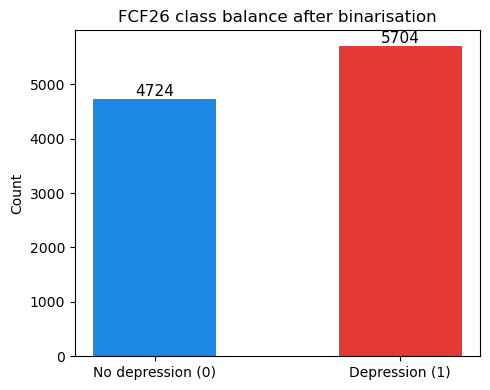

In [214]:
# Check class balance after binarisation
print('Training set class distribution:')
print(df_train['FCF26'].value_counts())
print(f"\nClass ratio: {df_train['FCF26'].mean():.3f} depression rate")

fig, ax = plt.subplots(figsize=(5, 4))
counts = df_train['FCF26'].value_counts().sort_index()
ax.bar(['No depression (0)', 'Depression (1)'], counts.values,
       color=['#1E88E5', '#E53935'], width=0.5)
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontsize=11)
ax.set_ylabel('Count')
ax.set_title('FCF26 class balance after binarisation')
plt.tight_layout()
plt.show()


The dataset is mildly imbalanced — approximately 55% depression, 45% no depression. This is not severe enough to require resampling techniques such as SMOTE, but it does motivate using `roc_auc` rather than accuracy as the cross-validation scoring metric, as accuracy can be misleading when classes are not perfectly balanced. We also note the model without any weighting tends to predict the majority class more readily, which we observe in the baseline recall scores.

### check for duplicates

In [215]:
df_train.duplicated().sum()

0

### outliers

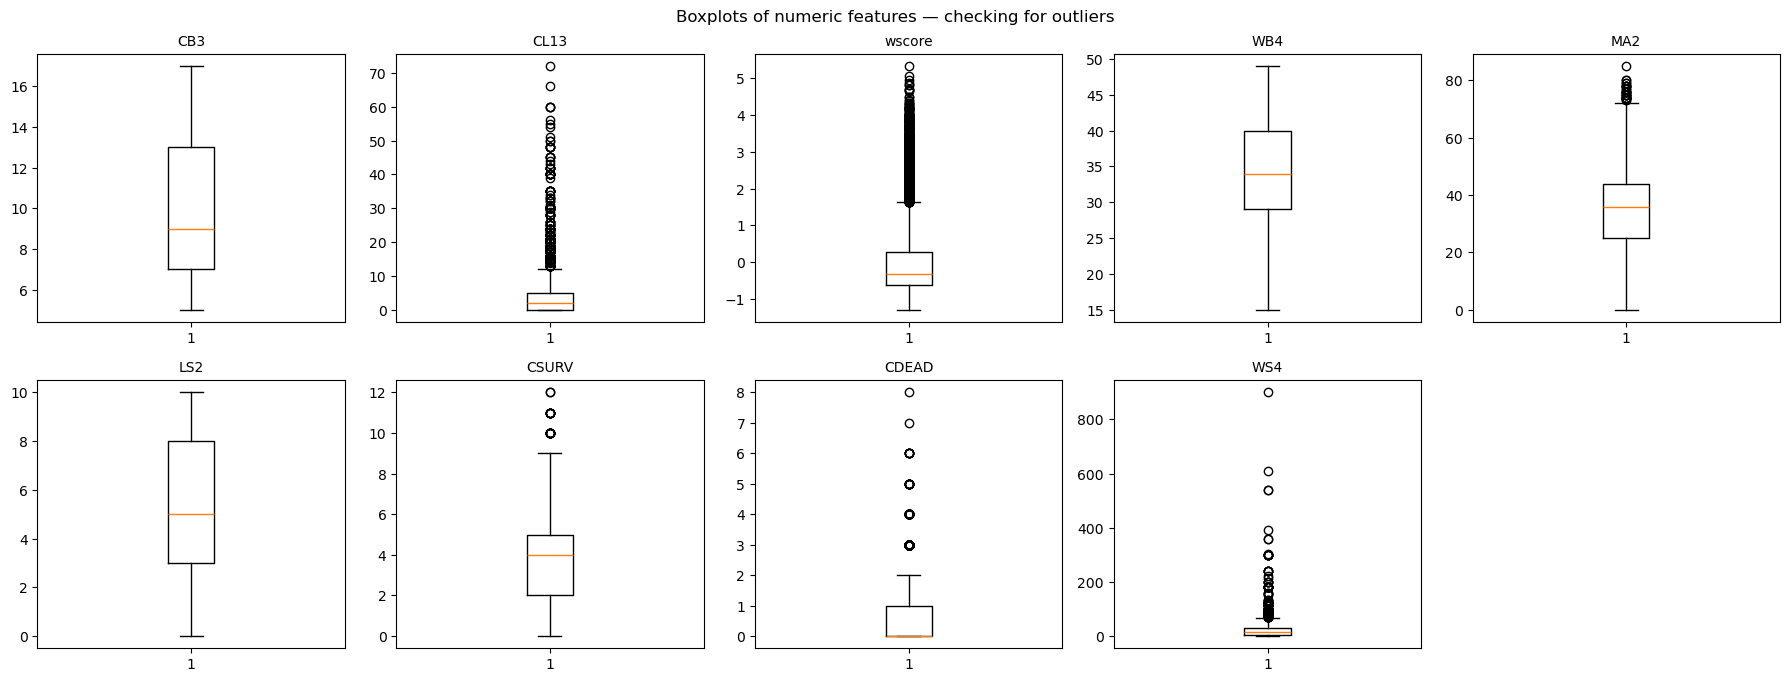

,CB3,CL13,wscore,WB4,MA2,LS2,CSURV,CDEAD,WS4
min,5.0,0.0,-1.30,15.0,0.0,0.0,0.0,0.0,0.0
max,17.0,72.0,5.34,49.0,85.0,10.0,12.0,8.0,900.0


In [216]:
# Numeric outlier check — boxplot of each numeric feature
# (following week 4 EDA approach: examine data before modelling)

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

numeric_to_check = ['CB3','CL13','wscore','WB4','MA2','LS2','CSURV','CDEAD','WS4']

for i, col in enumerate(numeric_to_check):
    axes[i].boxplot(df_train[col].dropna().astype(float))
    axes[i].set_title(col, fontsize=10)

# turn off unused axes
for j in range(len(numeric_to_check), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of numeric features — checking for outliers', fontsize=12)
plt.tight_layout()
plt.show()

# Print min/max for each
df_train[numeric_to_check].astype(float).describe().loc[['min','max']].round(2)


The boxplots show no extreme outliers requiring removal. `WS4` (water collection time) and `CDEAD` (number of deceased children) have right-skewed distributions with some high values, but these are plausible real values in this survey context — a household collecting water for a long time or a mother who has lost multiple children are both meaningful data points rather than errors. All numeric features are retained as-is and will be standardised by the `StandardScaler` in preprocessing.

In [217]:
df_train.head()

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5,FCF26
773,64.0,21.0,6.0,6.0,8.0,YES,PRIMARY,CLASS/YEAR/GRADE 1,YES,NO,...,NO,DUG WELL: UNPROTECTED WELL,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES,1
11211,941.0,6.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO,0
2464,203.0,19.0,2.0,2.0,12.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,YES,PIPED WATER: PIPED TO YARD / PLOT,IN OWN YARD / PLOT,0.0,"NO, ALWAYS SUFFICIENT",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,NO,1
11506,969.0,20.0,2.0,2.0,15.0,YES,PRIMARY,CLASS/GRADE 8,YES,NO,...,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,ELSEWHERE,YES,NO,1
5113,429.0,10.0,1.0,1.0,7.0,YES,PRIMARY,CLASS/YEAR/GRADE 2,YES,NO,...,YES,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,5.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,NO,1


### Dividing columns into categories: numeric, binary and categorical

In [219]:
numeric_cols = ['HH1', 'HH2', 'LN', 'FS4', 'CB3', 'CL13', 'wscore', 'WB4', 'MA2', 'LS2', 'CSURV', 'CDEAD', 'WS4']
df_train[numeric_cols].head()

,HH1,HH2,LN,FS4,CB3,CL13,wscore,WB4,MA2,LS2,CSURV,CDEAD,WS4
773,64.0,21.0,6.0,6.0,8.0,1.0,-0.49524,38.0,39.0,3,5.0,0.0,30.0
11211,941.0,6.0,2.0,2.0,14.0,6.0,-0.631197,36.0,71.0,1,5.0,0.0,30.0
2464,203.0,19.0,2.0,2.0,12.0,4.0,3.69758,27.0,33.0,6,1.0,0.0,0.0
11506,969.0,20.0,2.0,2.0,15.0,16.0,-0.780775,36.0,0.0,5,0.0,0.0,30.0
5113,429.0,10.0,1.0,1.0,7.0,0.0,-0.714153,25.0,27.0,7,2.0,1.0,5.0


Realised there are 'DK', not just 'NO RESPONSE'. Dealing with this before categorising the data.

In [220]:
(df_train == 'DK').sum().sort_values(ascending=False)

DV1A     37
DV1B     33
VT22C    32
VT1      27
VT22B    25
         ..
HH6       0
FCD5      0
FCD2K     0
FCD2J     0
FCF26     0
Length: 87, dtype: int64

insignificant number of DK, going for simple imputer

In [221]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='DK')
dk_cols = []
for col in df_train.columns:

    if (df_train[col] == 'DK').any():
        dk_cols.append(col)

df_train[dk_cols] = imputer.fit_transform(df_train[dk_cols])
df_test[dk_cols] = imputer.transform(df_test[dk_cols])

In [222]:
(df_train == 'DK').sum().sort_values(ascending=False)

HH1          0
TA1          0
CDEAD        0
CSURV        0
MSTATUS      0
            ..
ethnicity    0
HL4          0
HH7          0
HH6          0
FCF26        0
Length: 87, dtype: int64

In [223]:
df_train[numeric_cols] = df_train[numeric_cols].astype(float)
df_test[numeric_cols] = df_test[numeric_cols].astype(float)

In [224]:
binary_cols = [col for col in df_train.columns 
               if df_train[col].nunique() <= 2 and col not in numeric_cols]

df_train[binary_cols].head()

,CB4,CB11,HH6,HL4,WB5,DV1A,DV1B,DV1C,DV1D,DV1E,...,HC12,HC13,HC15,HC17,HC19,TN1,WS7,WS15,HW5,FCF26
773,YES,NO,Rural,Male,YES,NO,NO,NO,NO,NO,...,NO,NO,YES,YES,NO,NO,"NO, ALWAYS SUFFICIENT",NO,YES,1
11211,YES,NO,Rural,Male,YES,NO,NO,NO,NO,NO,...,YES,NO,YES,NO,NO,YES,"NO, ALWAYS SUFFICIENT",NO,NO,0
2464,YES,NO,Urban,Female,YES,NO,NO,NO,NO,NO,...,YES,YES,NO,NO,YES,YES,"NO, ALWAYS SUFFICIENT",NO,NO,1
11506,YES,NO,Rural,Female,NO,NO,NO,NO,NO,NO,...,NO,NO,YES,NO,NO,YES,"NO, ALWAYS SUFFICIENT",YES,NO,1
5113,YES,NO,Rural,Male,YES,NO,NO,NO,NO,NO,...,NO,NO,YES,YES,NO,YES,"NO, ALWAYS SUFFICIENT",NO,NO,1


In [225]:
cat_cols = [col for col in df_train.columns 
            if col not in numeric_cols and col not in binary_cols]
df_train[cat_cols].head()

,CB5A,CB5B,CB7,CL3,FCD2A,FCD2B,FCD2C,FCD2D,FCD2E,FCD2F,...,LS4,MSTATUS,HC4,HC5,HC8,HC14,WS1,WS3,WS11,WS14
773,PRIMARY,CLASS/YEAR/GRADE 1,YES,0.0,NO,YES,NO,YES,YES,NO,...,BETTER,Currently married/in union,EARTH / SAND,IRON SHEETS / METAL / TIN,NO,OWN,DUG WELL: UNPROTECTED WELL,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
11211,PRIMARY,CLASS/GRADE 7,YES,3.0,NO,YES,NO,NO,NO,NO,...,BETTER,Currently married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
2464,PRIMARY,CLASS/GRADE 6,YES,0.0,NO,YES,NO,YES,YES,NO,...,BETTER,Currently married/in union,CEMENT,IRON SHEETS / METAL / TIN,"YES, INTERCONNECTED GRID",RENT,PIPED WATER: PIPED TO YARD / PLOT,IN OWN YARD / PLOT,FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING
11506,PRIMARY,CLASS/GRADE 8,YES,1.0,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,...,BETTER,Never married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,ELSEWHERE
5113,PRIMARY,CLASS/YEAR/GRADE 2,YES,0.0,NO,YES,YES,YES,YES,NO,...,BETTER,Currently married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT


---
---

### Encoding binary columns

In [226]:
df_train[binary_cols] = df_train[binary_cols].replace({'YES': 1, 'NO': 0})
df_train[binary_cols] = df_train[binary_cols].replace({'True': 1, 'False': 0})
df_test[binary_cols] = df_test[binary_cols].replace({'YES': 1, 'NO': 0})
df_test[binary_cols] = df_test[binary_cols].replace({'True': 1, 'False': 0})

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_56405/3024638511.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train[binary_cols] = df_train[binary_cols].replace({'YES': 1, 'NO': 0})
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_56405/3024638511.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test[binary_cols] = df_test[binary_cols].replace({'YES': 1, 'NO': 0})


In [227]:
df_train[binary_cols].head()

,CB4,CB11,HH6,HL4,WB5,DV1A,DV1B,DV1C,DV1D,DV1E,...,HC12,HC13,HC15,HC17,HC19,TN1,WS7,WS15,HW5,FCF26
773,1,0,Rural,Male,1,0,0,0,0,0,...,0,0,1,1,0,0,"NO, ALWAYS SUFFICIENT",0,1,1
11211,1,0,Rural,Male,1,0,0,0,0,0,...,1,0,1,0,0,1,"NO, ALWAYS SUFFICIENT",0,0,0
2464,1,0,Urban,Female,1,0,0,0,0,0,...,1,1,0,0,1,1,"NO, ALWAYS SUFFICIENT",0,0,1
11506,1,0,Rural,Female,0,0,0,0,0,0,...,0,0,1,0,0,1,"NO, ALWAYS SUFFICIENT",1,0,1
5113,1,0,Rural,Male,1,0,0,0,0,0,...,0,0,1,1,0,1,"NO, ALWAYS SUFFICIENT",0,0,1


In [228]:
vt22_cols = [col for col in df_train.columns if col.startswith('VT22') and 'severity' not in col]
fcd2_cols = [col for col in df_train.columns if col.startswith('FCD2') and 'severity' not in col]

for df in [df_train, df_test]:    
    df['VT22_severity'] = df[vt22_cols].sum(axis=1)

    severity = df[fcd2_cols].apply(lambda col: col.map({'YES': 2, 'NO RESPONSE': 1, 'NO': 0}))
    df['FCD2_severity'] = severity.sum(axis=1)
    
    df.drop(columns=fcd2_cols, inplace=True)
    df.drop(columns=vt22_cols, inplace=True)

numeric_cols = numeric_cols + ['VT22_severity', 'FCD2_severity']

In [229]:
# Verify FCD2_severity is not all zeros
print('FCD2_severity value counts:')
print(df_train['FCD2_severity'].value_counts().head(10))
print(f'\nStd dev: {df_train["FCD2_severity"].std():.4f}')
print('Note: if std=0 this column is all zeros and will be dropped in feature selection')


FCD2_severity value counts:
FCD2_severity
11    1449
8     1356
6     1295
10    1211
12    1076
4     1069
14     739
2      692
16     590
18     376
Name: count, dtype: int64

Std dev: 4.6218
Note: if std=0 this column is all zeros and will be dropped in feature selection


In [230]:
df_train[['VT22_severity']].describe()

,VT22_severity
count,10428.000000
mean,0.360472
std,0.818178
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,7.000000


In [231]:
df_train.CL2 = df_train.CL2.astype(int)
df_test.CL2 = df_test.CL2.astype(int)
df_train.CL12 = df_train.CL12.astype(int)
df_test.CL12 =df_test.CL12.astype(int)

In [232]:
df_train = df_train.rename(columns={'HH6': 'HH6_urban'})
df_test = df_test.rename(columns={'HH6': 'HH6_urban'})

encoder = OneHotEncoder(
    categories=[['Rural', 'Urban']], 
    drop=['Rural'],
    sparse_output=False
)

df_train[['HH6_urban']] = encoder.fit_transform(df_train[['HH6_urban']])
df_test[['HH6_urban']] = encoder.transform(df_test[['HH6_urban']])

df_train = df_train.rename(columns={'HL4': 'HL4_female'})
df_test = df_test.rename(columns={'HL4': 'HL4_female'})

encoder = OneHotEncoder(
    categories=[['Male', 'Female']], 
    drop=['Male'],
    sparse_output=False
)

df_train[['HL4_female']] = encoder.fit_transform(df_train[['HL4_female']])
df_test[['HL4_female']] = encoder.transform(df_test[['HL4_female']])

In [233]:
df_train.disability.unique()

array(['Has no functional difficulty', 'Has functional difficulty'],
      dtype=object)

In [234]:
encoder = OneHotEncoder(
    categories=[['Has no functional difficulty', 'Has functional difficulty']], 
    drop=['Has no functional difficulty'],
    sparse_output=False
)

df_train[['disability']] = encoder.fit_transform(df_train[['disability']])
df_test[['disability']] = encoder.transform(df_test[['disability']])

In [235]:
df_train.WS7.unique()

array(['NO, ALWAYS SUFFICIENT', 'YES, AT LEAST ONCE'], dtype=object)

In [236]:
df_train = df_train.rename(columns={'WS7': 'WS7_sufficient'})
df_test = df_test.rename(columns={'WS7': 'WS7_sufficient'})

encoder = OneHotEncoder(
    categories=[['NO, ALWAYS SUFFICIENT', 'YES, AT LEAST ONCE']], 
    drop=['YES, AT LEAST ONCE'],
    sparse_output=False
)

df_train[['WS7_sufficient']] = encoder.fit_transform(df_train[['WS7_sufficient']])
df_test[['WS7_sufficient']] = encoder.transform(df_test[['WS7_sufficient']])

In [237]:
binary_cols = [col for col in df_train.columns 
               if df_train[col].nunique() <= 2 and col not in numeric_cols]
df_train[binary_cols] = df_train[binary_cols].astype(int)
df_test[binary_cols] = df_test[binary_cols].astype(int)
df_train[binary_cols].head()

,CB4,CB11,HH6_urban,HL4_female,WB5,DV1A,DV1B,DV1C,DV1D,DV1E,...,HC12,HC13,HC15,HC17,HC19,TN1,WS7_sufficient,WS15,HW5,FCF26
773,1,0,0,0,1,0,0,0,0,0,...,0,0,1,1,0,0,1,0,1,1
11211,1,0,0,0,1,0,0,0,0,0,...,1,0,1,0,0,1,1,0,0,0
2464,1,0,1,1,1,0,0,0,0,0,...,1,1,0,0,1,1,1,0,0,1
11506,1,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,1,1,1,0,1
5113,1,0,0,0,1,0,0,0,0,0,...,0,0,1,1,0,1,1,0,0,1


### numeric values — scaling, as they're in different ranges

In [238]:
num_scaler = StandardScaler()

df_train[numeric_cols] = num_scaler.fit_transform(df_train[numeric_cols])
df_test[numeric_cols] = num_scaler.transform(df_test[numeric_cols])
df_train[numeric_cols].head()


,HH1,HH2,LN,FS4,CB3,CL13,wscore,WB4,MA2,LS2,CSURV,CDEAD,WS4,VT22_severity,FCD2_severity
773,-1.512910,1.144769,7.444528,7.444528,-0.513774,-0.436858,-0.523937,0.495406,0.436487,-0.723919,0.691838,-0.497244,0.293070,0.781687,-0.750540
11211,1.216532,-0.928916,0.438546,0.438546,1.151639,0.444533,-0.659752,0.219697,2.157047,-1.361910,0.691838,-0.497244,0.293070,-0.440600,-1.616054
2464,-1.080308,0.868278,0.438546,0.438546,0.596502,0.091976,3.664467,-1.020992,0.113882,0.233067,-1.529370,-0.497244,-0.751906,-0.440600,-0.317783
11506,1.303675,1.006524,0.438546,0.438546,1.429208,2.207315,-0.809172,0.219697,-1.660445,-0.085928,-2.084673,-0.497244,0.293070,-0.440600,0.331353
5113,-0.376939,-0.375933,-1.312950,-1.312950,-0.791343,-0.613136,-0.742620,-1.296701,-0.208723,0.552063,-0.974068,0.844002,-0.577743,-0.440600,-0.317783


### categorical values

In [239]:
binary_cols = [col for col in df_train.columns 
               if df_train[col].nunique() <= 2 and col not in numeric_cols]
df_train[binary_cols] = df_train[binary_cols].astype(int)
df_test[binary_cols] = df_test[binary_cols].astype(int)
df_train[binary_cols].head()

,CB4,CB11,HH6_urban,HL4_female,WB5,DV1A,DV1B,DV1C,DV1D,DV1E,...,HC12,HC13,HC15,HC17,HC19,TN1,WS7_sufficient,WS15,HW5,FCF26
773,1,0,0,0,1,0,0,0,0,0,...,0,0,1,1,0,0,1,0,1,1
11211,1,0,0,0,1,0,0,0,0,0,...,1,0,1,0,0,1,1,0,0,0
2464,1,0,1,1,1,0,0,0,0,0,...,1,1,0,0,1,1,1,0,0,1
11506,1,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,1,1,1,0,1
5113,1,0,0,0,1,0,0,0,0,0,...,0,0,1,1,0,1,1,0,0,1


In [240]:
cat_cols = [col for col in df_train.columns 
            if col not in numeric_cols and col not in binary_cols]
df_train[cat_cols].head()

,CB5A,CB5B,CB7,CL3,FCD5,HH7,ethnicity,WB6A,WB6B,WB14,...,LS4,MSTATUS,HC4,HC5,HC8,HC14,WS1,WS3,WS11,WS14
773,PRIMARY,CLASS/YEAR/GRADE 1,YES,0.0,YES,North,Chewa,PRIMARY,CLASS/YEAR/GRADE 5,CANNOT READ AT ALL,...,BETTER,Currently married/in union,EARTH / SAND,IRON SHEETS / METAL / TIN,NO,OWN,DUG WELL: UNPROTECTED WELL,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
11211,PRIMARY,CLASS/GRADE 7,YES,3.0,NO,South,Sena,PRIMARY,CLASS/YEAR/GRADE 5,ABLE TO READ WHOLE SENTENCE,...,BETTER,Currently married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
2464,PRIMARY,CLASS/GRADE 6,YES,0.0,YES,North,Chewa,HIGHER,CLASS/YEAR/GRADE 1,ABLE TO READ WHOLE SENTENCE,...,BETTER,Currently married/in union,CEMENT,IRON SHEETS / METAL / TIN,"YES, INTERCONNECTED GRID",RENT,PIPED WATER: PIPED TO YARD / PLOT,IN OWN YARD / PLOT,FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING
11506,PRIMARY,CLASS/GRADE 8,YES,1.0,NO RESPONSE,South,Other ethnicity,PRIMARY,CLASS/GRADE 8,ABLE TO READ WHOLE SENTENCE,...,BETTER,Never married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,ELSEWHERE
5113,PRIMARY,CLASS/YEAR/GRADE 2,YES,0.0,NO,Central,Chewa,PRIMARY,CLASS/GRADE 7,ABLE TO READ WHOLE SENTENCE,...,BETTER,Currently married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT


In [241]:
for col in cat_cols:
    print(df_train[col].value_counts())
    print(f"\n")

CB5A
PRIMARY            8802
NOT SCHOOL AGE      711
ECE                 496
LOWER SECONDARY     293
UPPER SECONDARY     121
HIGHER                5
Name: count, dtype: int64


CB5B
CLASS/YEAR/GRADE 1    2307
CLASS/YEAR/GRADE 2    1666
CLASS/YEAR/GRADE 3    1412
NOT SCHOOL AGE        1206
CLASS/YEAR/GRADE 4    1102
CLASS/YEAR/GRADE 5     964
CLASS/GRADE 6          774
CLASS/GRADE 7          582
CLASS/GRADE 8          415
Name: count, dtype: int64


CB7
YES               9239
NOT SCHOOL AGE     710
NO                 479
Name: count, dtype: int64


CL3
0.0     7935
2.0      544
1.0      472
3.0      383
4.0      224
5.0      199
6.0      123
7.0       73
10.0      71
8.0       58
12.0      44
9.0       40
14.0      40
30.0      29
20.0      28
21.0      22
15.0      21
18.0      14
35.0      11
24.0      10
16.0       9
22.0       8
11.0       7
42.0       6
13.0       6
28.0       6
60.0       6
36.0       5
40.0       4
27.0       4
25.0       4
23.0       3
63.0       3
32.0       2


In [242]:
for col in cat_cols:
    print(df_train[col].value_counts())
    print(f"\n")

CB5A
PRIMARY            8802
NOT SCHOOL AGE      711
ECE                 496
LOWER SECONDARY     293
UPPER SECONDARY     121
HIGHER                5
Name: count, dtype: int64


CB5B
CLASS/YEAR/GRADE 1    2307
CLASS/YEAR/GRADE 2    1666
CLASS/YEAR/GRADE 3    1412
NOT SCHOOL AGE        1206
CLASS/YEAR/GRADE 4    1102
CLASS/YEAR/GRADE 5     964
CLASS/GRADE 6          774
CLASS/GRADE 7          582
CLASS/GRADE 8          415
Name: count, dtype: int64


CB7
YES               9239
NOT SCHOOL AGE     710
NO                 479
Name: count, dtype: int64


CL3
0.0     7935
2.0      544
1.0      472
3.0      383
4.0      224
5.0      199
6.0      123
7.0       73
10.0      71
8.0       58
12.0      44
9.0       40
14.0      40
30.0      29
20.0      28
21.0      22
15.0      21
18.0      14
35.0      11
24.0      10
16.0       9
22.0       8
11.0       7
42.0       6
13.0       6
28.0       6
60.0       6
36.0       5
40.0       4
27.0       4
25.0       4
23.0       3
63.0       3
32.0       2


In [243]:
df_train = df_train[df_train['MSTATUS'] != '9.0']
df_test = df_test[df_test['MSTATUS'] != '9.0']

In [244]:
safety_encoder = OrdinalEncoder(
    categories=[
        ['VERY UNSAFE', 'UNSAFE', 'NEVER WALK ALONE AFTER DARK', 'SAFE', 'VERY SAFE'],
        ['VERY UNSAFE', 'UNSAFE', 'NEVER WALK ALONE AFTER DARK', 'SAFE', 'VERY SAFE']
    ]
)

df_train[['VT20', 'VT21']] = safety_encoder.fit_transform(df_train[['VT20', 'VT21']])
df_test[['VT20', 'VT21']] = safety_encoder.transform(df_test[['VT20', 'VT21']])

In [245]:
happiness_encoder = OrdinalEncoder(
    categories=[
        ['VERY UNHAPPY', 'SOMEWHAT UNHAPPY', 'NEITHER HAPPY NOR UNHAPPY', 'SOMEWHAT HAPPY', 'VERY HAPPY']
    ]
)

df_train[['LS1']] = happiness_encoder.fit_transform(df_train[['LS1']])
df_test[['LS1']] = happiness_encoder.transform(df_test[['LS1']])

In [246]:
literacy_encoder = OrdinalEncoder(
    categories=[
        ['CANNOT READ AT ALL', 'ABLE TO READ ONLY PARTS OF SENTENCE', 'ABLE TO READ WHOLE SENTENCE', 'NO SENTENCE IN REQUIRED LANGUAGE / BRAILLE']
        ]
)

df_train[['WB14']] = literacy_encoder.fit_transform(df_train[['WB14']])
df_test[['WB14']] = literacy_encoder.transform(df_test[['WB14']])

In [247]:
water_cat_0 = ['SURFACE WATER (RIVER, DAM, LAKE, POND, STREAM, CANAL, IRRIGATION CHANNEL)', 'RAINWATER', 'OTHER']
water_cat_1 = ['CART WITH SMALL TANK', 'TANKER-TRUCK', 'SPRING: UNPROTECTED SPRING']
water_cat_2 = ['DUG WELL: UNPROTECTED WELL', 'SPRING: PROTECTED SPRING', 'DUG WELL: PROTECTED WELL']
water_cat_3 = ['WATER KIOSK', 'TUBE WELL / BOREHOLE', 'PIPED WATER: PIPED TO NEIGHBOUR']
water_cat_4 = ['PIPED WATER: PUBLIC TAP / STANDPIPE', 'PIPED WATER: PIPED TO YARD / PLOT', 'PIPED WATER: PIPED INTO DWELLING', 'PACKAGED WATER: BOTTLED WATER']

df_train['WS1'] = df_train['WS1'].replace(water_cat_0, 0)
df_test['WS1'] = df_test['WS1'].replace(water_cat_0, 0)
df_train['WS1'] = df_train['WS1'].replace(water_cat_1, 1)
df_test['WS1'] = df_test['WS1'].replace(water_cat_1, 1)
df_train['WS1'] = df_train['WS1'].replace(water_cat_2, 2)
df_test['WS1'] = df_test['WS1'].replace(water_cat_2, 2)
df_train['WS1'] = df_train['WS1'].replace(water_cat_3, 3)
df_test['WS1'] = df_test['WS1'].replace(water_cat_3, 3)
df_train['WS1'] = df_train['WS1'].replace(water_cat_4, 4)
df_test['WS1'] = df_test['WS1'].replace(water_cat_4, 4)

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_56405/815513190.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['WS1'] = df_train['WS1'].replace(water_cat_4, 4)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_56405/815513190.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['WS1'] = df_test['WS1'].replace(water_cat_4, 4)


In [248]:
ethnicity_encoder = OrdinalEncoder(
    categories=[['Chewa', 'Lomwe', 'Ngoni', 'Yao', 'Tumbuka', 'Other ethnicity', 'Sena', 'Tonga', 'Nkhonde']],
)

df_train[['ethnicity']] = ethnicity_encoder.fit_transform(df_train[['ethnicity']])
df_test[['ethnicity']] = ethnicity_encoder.transform(df_test[['ethnicity']])

Note: `OrdinalEncoder` on ethnicity imposes a numeric ordering (Chewa=0, Lomwe=1, etc.) which has no inherent meaning. This is a simplification — ideally ethnicity would be one-hot encoded, but with 9 categories this would add 8 columns. Given that ethnicity shows a very weak correlation with the target (|r| = 0.019, below the 0.02 threshold), it will be dropped in the feature selection step regardless, so the encoding choice does not affect the final model.

In [249]:
df_train['CL3'] = pd.cut(df_train['CL3'],
                          bins=[-1, 0, 2, 5, 10, 77],
                          labels=[0, 1, 2, 3, 4])

df_test['CL3'] = pd.cut(df_test['CL3'],
                         bins=[-1, 0, 2, 5, 10, 77],
                         labels=[0, 1, 2, 3, 4])

In [250]:
for col in cat_cols:
    print(df_train[col].value_counts())
    print(f"\n")

CB5A
PRIMARY            8801
NOT SCHOOL AGE      711
ECE                 496
LOWER SECONDARY     293
UPPER SECONDARY     121
HIGHER                5
Name: count, dtype: int64


CB5B
CLASS/YEAR/GRADE 1    2307
CLASS/YEAR/GRADE 2    1665
CLASS/YEAR/GRADE 3    1412
NOT SCHOOL AGE        1206
CLASS/YEAR/GRADE 4    1102
CLASS/YEAR/GRADE 5     964
CLASS/GRADE 6          774
CLASS/GRADE 7          582
CLASS/GRADE 8          415
Name: count, dtype: int64


CB7
YES               9238
NOT SCHOOL AGE     710
NO                 479
Name: count, dtype: int64


CL3
0    7934
1    1016
2     806
3     365
4     306
Name: count, dtype: int64


FCD5
NO             5439
YES            3544
NO RESPONSE    1444
Name: count, dtype: int64


HH7
South      4870
Central    3447
North      2110
Name: count, dtype: int64


ethnicity
0.0    3120
1.0    1886
2.0    1252
3.0    1156
4.0    1024
5.0     928
6.0     519
7.0     372
8.0     170
Name: count, dtype: int64


WB6A
PRIMARY                8343
LOWER SECOND

In [251]:
floor_cat_0 = ['EARTH / SAND', 'DUNG', 'OTHER']
floor_cat_1 = ['PALM / BAMBOO', 'WOOD PLANKS']
floor_cat_2 = ['VINYL OR ASPHALT STRIPS', 'CARPET']
floor_cat_3 = ['CEMENT']
floor_cat_4 = ['PARQUET OR POLISHED WOOD', 'CERAMIC TILES']

df_train['HC4'] = df_train['HC4'].replace(floor_cat_0, 0)
df_test['HC4'] = df_test['HC4'].replace(floor_cat_0, 0)
df_train['HC4'] = df_train['HC4'].replace(floor_cat_1, 1)
df_test['HC4'] = df_test['HC4'].replace(floor_cat_1, 1)
df_train['HC4'] = df_train['HC4'].replace(floor_cat_2, 2)
df_test['HC4'] = df_test['HC4'].replace(floor_cat_2, 2)
df_train['HC4'] = df_train['HC4'].replace(floor_cat_3, 3)
df_test['HC4'] = df_test['HC4'].replace(floor_cat_3, 3)
df_train['HC4'] = df_train['HC4'].replace(floor_cat_4, 4)
df_test['HC4'] = df_test['HC4'].replace(floor_cat_4, 4)

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_56405/1322362266.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['HC4'] = df_train['HC4'].replace(floor_cat_4, 4)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_56405/1322362266.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['HC4'] = df_test['HC4'].replace(floor_cat_4, 4)


In [252]:
roof_cat_0 = ['NO ROOF', 'OTHER']
roof_cat_1 = ['THATCH / PALM LEAF', 'RUSTIC MAT', 'PALM / BAMBOO']
roof_cat_2 = ['WOOD','WOOD PLANKS', 'IRON SHEETS / METAL / TIN']
roof_cat_3 = ['CEMENT', 'CALAMINE / CEMENT FIBRE']
roof_cat_4 = ['CERAMIC TILES', 'ROOFING SHINGLES']

df_train['HC5'] = df_train['HC5'].replace(roof_cat_0, 0)
df_test['HC5'] = df_test['HC5'].replace(roof_cat_0, 0)
df_train['HC5'] = df_train['HC5'].replace(roof_cat_1, 1)
df_test['HC5'] = df_test['HC5'].replace(roof_cat_1, 1)
df_train['HC5'] = df_train['HC5'].replace(roof_cat_2, 2)
df_test['HC5'] = df_test['HC5'].replace(roof_cat_2, 2)
df_train['HC5'] = df_train['HC5'].replace(roof_cat_3, 3)
df_test['HC5'] = df_test['HC5'].replace(roof_cat_3, 3)
df_train['HC5'] = df_train['HC5'].replace(roof_cat_4, 4)
df_test['HC5'] = df_test['HC5'].replace(roof_cat_4, 4)

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_56405/350311648.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['HC5'] = df_train['HC5'].replace(roof_cat_4, 4)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_56405/350311648.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['HC5'] = df_test['HC5'].replace(roof_cat_4, 4)


In [253]:
cat_2 = ['YES', 'YES, INTERCONNECTED GRID',
          'NO DIFFICULTY', 
          'South', 
          'CLASS/YEAR/GRADE 4','CLASS/YEAR/GRADE 5','CLASS/GRADE 6','CLASS/GRADE 7','CLASS/GRADE 8','LOWER SECONDARY', 'UPPER SECONDARY', 'HIGHER', 'VOCATIONAL TRAINING', 
          'IMPROVED', 'BETTER', 
          'OWN', 'IN OWN DWELLING', 
          'Currently married/in union',
          'FLUSH / POUR FLUSH: FLUSH TO PIPED SEWER SYSTEM',
          'FLUSH / POUR FLUSH: FLUSH TO PIT LATRINE',
          'FLUSH / POUR FLUSH: FLUSH TO DK WHERE',
          'FLUSH / POUR FLUSH: FLUSH TO OPEN DRAIN',
          'FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK'
          ]

cat_1 = ['YES, OFF-GRID (GENERATOR/ISOLATED SYSTEM)',
         'NOT SCHOOL AGE', 
         'NOT MARRIED', 
         'OTHER',
         'SOME DIFFICULTY', 
         'NO RESPONSE', 
         'Central', 
         'MORE OR LESS THE SAME', 
         'RENT', 
         'IN OWN YARD / PLOT', 
         'Never married/in union', 
         'PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT',
         'PIT LATRINE: PIT LATRINE WITH SLAB',
         'PIT LATRINE: VENTILATED IMPROVED PIT LATRINE',]

cat_0 = ['NO', 'A LOT OF DIFFICULTY', 
         'North', 
         'PRIMARY', 'ECE', 'CLASS/YEAR/GRADE 1','CLASS/YEAR/GRADE 2','CLASS/YEAR/GRADE 3', 
         'WORSE','WORSENED', 
         'ELSEWHERE', 'NO TOILET', 
         'Formerly married/in union',
         'NO FACILITY / BUSH / FIELD',
         'COMPOSTING TOILET',
         'HANGING TOILET / HANGING LATRINE']

df_train[cat_cols] = df_train[cat_cols].replace(cat_2, 2)
df_test[cat_cols] = df_test[cat_cols].replace(cat_2, 2)

df_train[cat_cols] = df_train[cat_cols].replace(cat_1, 1)
df_test[cat_cols] = df_test[cat_cols].replace(cat_1, 1)

df_train[cat_cols] = df_train[cat_cols].replace(cat_0, 0)
df_test[cat_cols] = df_test[cat_cols].replace(cat_0, 0)


/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_56405/2633748251.py:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train[cat_cols] = df_train[cat_cols].replace(cat_1, 1)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_56405/2633748251.py:44: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test[cat_cols] = df_test[cat_cols].replace(cat_1, 1)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_56405/2633748251.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be remove

In [254]:
df_train.to_csv('df_train.csv', index=True)
df_test.to_csv('df_test.csv', index=True)

In [255]:
len(numeric_cols)

15

In [256]:
len(binary_cols)

28

In [257]:
len(cat_cols)

28

In [258]:
# Continuing from preprocessing above
# numeric_cols, binary_cols, cat_cols, df_train, df_test already defined
# cleaned feature lists (get rid of the admin IDs, zero-variance col, and target)

target = 'FCF26'
admin_cols = ['HH1', 'HH2', 'LN', 'FS4']

feat_numeric = [c for c in df_train.columns
                if df_train[c].dtype == 'float64'
                and c not in admin_cols + [target]]

feat_binary  = [c for c in df_train.columns
                if df_train[c].dtype == 'int64'
                and df_train[c].nunique() == 2
                and c != target]

feat_cat     = [c for c in df_train.columns
                if c not in feat_numeric + feat_binary
                and c not in admin_cols + [target]]

all_features = feat_numeric + feat_binary + feat_cat

print(f'numeric: {len(feat_numeric)}  binary: {len(feat_binary)}  cat: {len(feat_cat)}')
print(f'Target: {target}  |  0={( df_train[target]==0).sum()}  1={(df_train[target]==1).sum()}')


numeric: 16  binary: 30  cat: 20
Target: FCF26  |  0=4723  1=5704


In [259]:
# data structure and descriptive statistics
df_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 10427 entries, 773 to 3135
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   HH1             10427 non-null  float64 
 1   HH2             10427 non-null  float64 
 2   LN              10427 non-null  float64 
 3   FS4             10427 non-null  float64 
 4   CB3             10427 non-null  float64 
 5   CB4             10427 non-null  int64   
 6   CB5A            10427 non-null  int64   
 7   CB5B            10427 non-null  int64   
 8   CB7             10427 non-null  int64   
 9   CB11            10427 non-null  int64   
 10  CL3             10427 non-null  category
 11  CL13            10427 non-null  float64 
 12  FCD5            10427 non-null  int64   
 13  HH6_urban       10427 non-null  int64   
 14  HH7             10427 non-null  int64   
 15  HL4_female      10427 non-null  int64   
 16  ethnicity       10427 non-null  float64 
 17  wscore          

In [260]:
df_train[feat_numeric].describe()


,CB3,CL13,ethnicity,wscore,WB4,WB14,VT20,VT21,MA2,LS1,LS2,CSURV,CDEAD,WS4,VT22_severity,FCD2_severity
count,10427.000000,10427.000000,10427.000000,10427.000000,10427.000000,10427.000000,10427.000000,10427.000000,10427.000000,10427.000000,10427.000000,10427.000000,10427.000000,10427.000000,10427.000000,10427.000000
mean,0.000076,0.000008,2.270260,0.000056,0.000085,1.242735,2.314088,2.934305,-0.000006,2.765513,0.000008,0.000093,0.000048,-0.000128,0.000042,0.000113
std,1.000066,1.000096,2.210234,1.000079,1.000059,0.930886,1.012883,1.027812,1.000096,1.293333,1.000096,1.000050,1.000084,1.000010,1.000087,1.000029
min,-1.346480,-0.613136,0.000000,-1.330647,-2.675245,0.000000,0.000000,0.000000,-1.660445,0.000000,-1.680905,-2.084673,-0.497244,-0.751906,-0.440600,-2.048812
25%,-0.791343,-0.613136,0.000000,-0.665878,-0.745284,0.000000,2.000000,3.000000,-0.316258,2.000000,-0.723919,-0.974068,-0.497244,-0.577743,-0.440600,-0.750540
50%,-0.236205,-0.260580,2.000000,-0.355013,-0.056012,2.000000,2.000000,3.000000,0.275185,3.000000,-0.085928,0.136536,-0.497244,-0.229418,-0.440600,0.114974
75%,0.874070,0.268255,4.000000,0.240749,0.771115,2.000000,3.000000,4.000000,0.705324,4.000000,0.871058,0.691838,0.844002,0.293070,-0.440600,0.547732
max,1.984346,12.078893,8.000000,5.302483,2.011804,3.000000,4.000000,4.000000,2.909792,4.000000,1.509049,4.578952,10.232721,30.597389,8.115410,2.711518


In [261]:
target_corr = (
    df_train[all_features + [target]]
    .corr()[target]
    .drop(target)
    .abs()
    .sort_values(ascending=False))

print(target_corr)


LS1              0.121039
VT22_severity    0.108480
LS2              0.103839
LS3              0.089755
VT20             0.082093
                   ...   
CB5A             0.003657
FCD5             0.002827
WB6B             0.000545
DV1E             0.000126
WB14             0.000091
Name: FCF26, Length: 66, dtype: float64


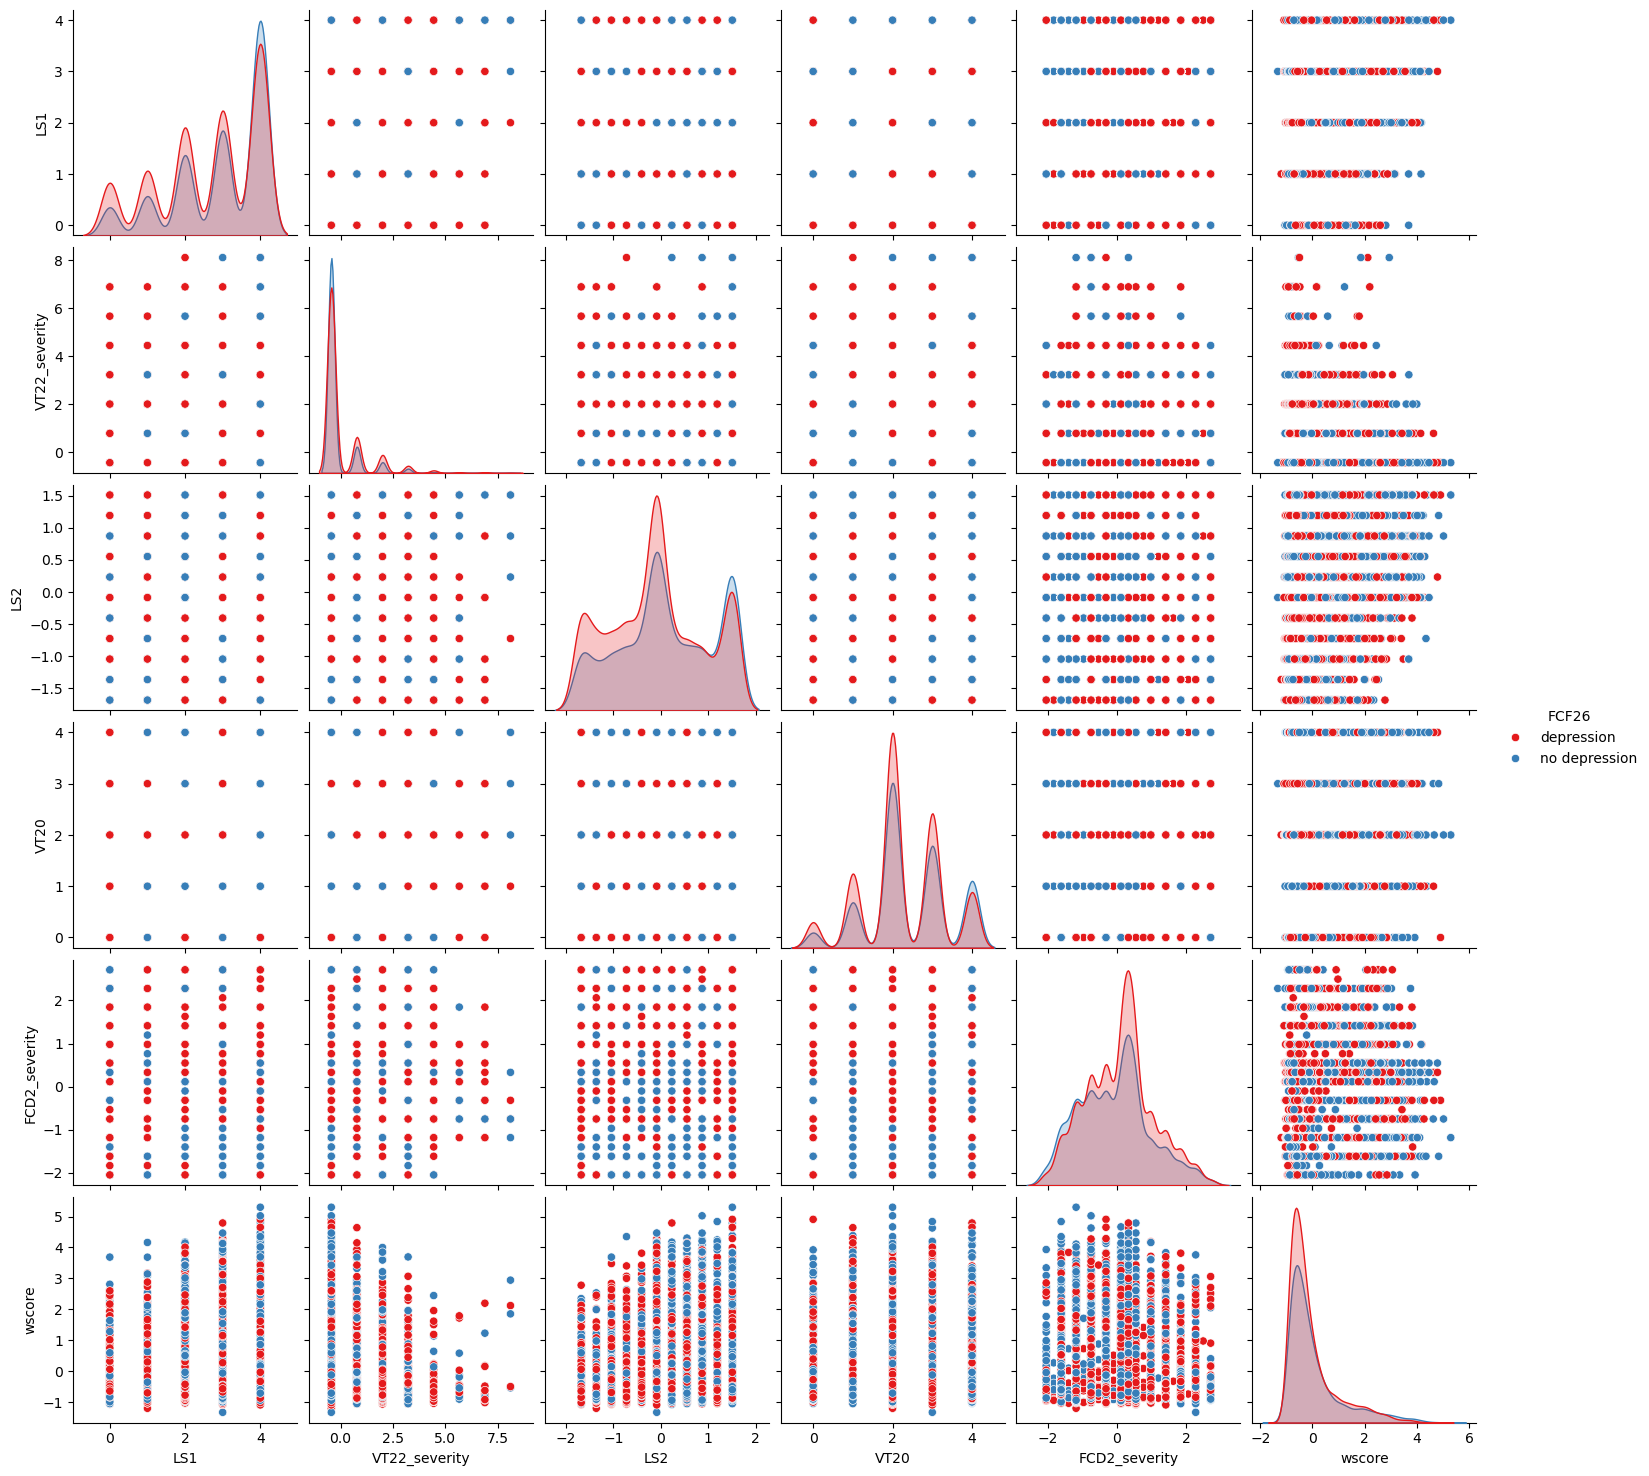

In [262]:
# From week 4 Exercise 1b: pairplot coloured by target
# Top 6 numeric features to keep the plot readable
target_corr = (
    df_train[all_features + [target]]
    .corr()[target]
    .drop(target)
    .abs()
    .sort_values(ascending=False))

top_num = target_corr[target_corr.index.isin(feat_numeric)].head(6).index.tolist()

plot_df = df_train[top_num + [target]].copy()
plot_df[target] = plot_df[target].map({0: 'no depression', 1: 'depression'})

sns.pairplot(plot_df, hue=target,
             vars=top_num, diag_kind='kde', palette='Set1')
plt.show()


In [263]:
print(target_corr[top_num])

LS1              0.121039
VT22_severity    0.108480
LS2              0.103839
VT20             0.082093
FCD2_severity    0.078871
wscore           0.060152
Name: FCF26, dtype: float64


In [264]:
df_train[top_num].corr().round(3)


,LS1,VT22_severity,LS2,VT20,FCD2_severity,wscore
LS1,1.000,-0.148,0.453,0.065,-0.051,0.119
VT22_severity,-0.148,1.000,-0.113,-0.047,0.052,-0.048
LS2,0.453,-0.113,1.000,0.074,-0.029,0.191
VT20,0.065,-0.047,0.074,1.000,0.002,0.033
FCD2_severity,-0.051,0.052,-0.029,0.002,1.000,-0.001
wscore,0.119,-0.048,0.191,0.033,-0.001,1.000


LS1 (mother's life satisfaction) - the clearest separation in the whole plot. The red curve (depressed children) peaks higher and to the right, meaning mothers of depressed children tend to report higher life satisfaction scores. This seems counterintuitive but maybe higher satisfaction may correlate with more engaged parenting which also means depression is more likely to be noticed and reported.

VT22_severity (violence severity composite) - sharp spike near zero for both classes, but the red distribution has a longer right tail. Children with higher violence severity scores are more likely to be depressed, which makes sense.

LS2 (number of siblings / household size) - three distinct peaks reflecting the discrete ordinal levels. average separation between classes. Correlated with LS1 (r = 0.45) which is visible in their scatter panel - the most structured panel in the plot ( apart from diagonals OBVS)

VT20 (type of violence witnessed by the mother) - 5-peaked KDE reflecting its 5 ordinal levels. smaller separation between red and blue curves, consistent with its weaker correlation (|r| = 0.08).

wscore (household wealth score) - continuous feature, smooth spread of dots in its scatter panels rather than grid patterns. The KDE shows almost complete overlap between depressed and non-depressed children. Wealth alone is a weak predictor of child depression once other factors are included.
VT21 (type of violence experienced by the mother) - nearly identical distributions for both classes. Weakest feature of the six (|r| = 0.05). Correlated with VT20 (r = 0.43) which explains the strong diagonal banding in their shared scatter panel.

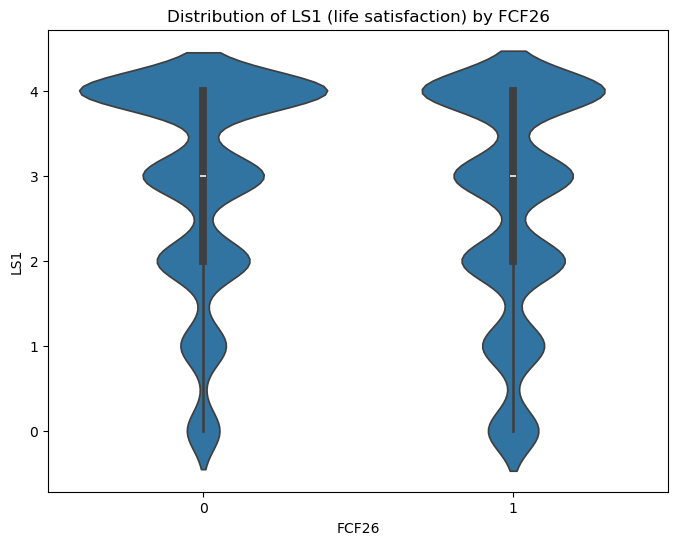

In [265]:
# From week 4 Exercise 1b: violin plot to visualise distribution vs target
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_train, x=target, y='LS1')
plt.title('Distribution of LS1 (life satisfaction) by FCF26')
plt.show()


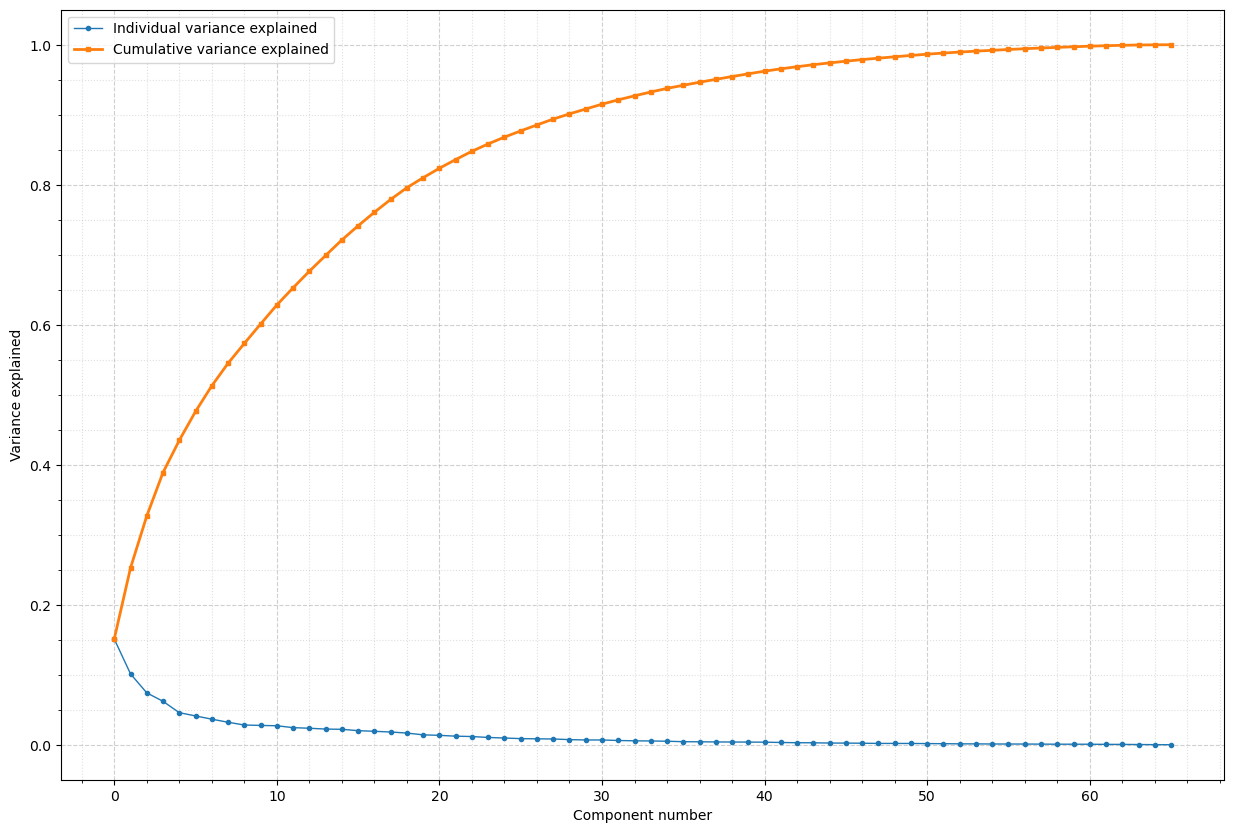

In [266]:
# From week 2 Exercise 11: scree plot of variance explained
from sklearn.decomposition import PCA

X = df_train[all_features].values

pca = PCA()
pca.fit(X)

var_ratio = pca.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)

plt.figure(figsize=(15, 10))
plt.plot(var_ratio, marker='o', markersize=3, linewidth=1, label='Individual variance explained')
plt.plot(cum_var, marker='s', markersize=3, linewidth=2, label='Cumulative variance explained')
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':', alpha=0.4)
plt.minorticks_on()
plt.xlabel('Component number')
plt.ylabel('Variance explained')
plt.legend()
plt.show()


The blue line shows how much variance each individual principal component explains - it drops off steeply after the first few components. The orange line is the cumulative variance - you need around 10 components to explain 65% of variance and around 30 to explain 90%.

no clear elbow - features are not highly correlated with each other and each one carries a bit of independent information. potential justification for not using PCA dimensionality reduction before modelling 

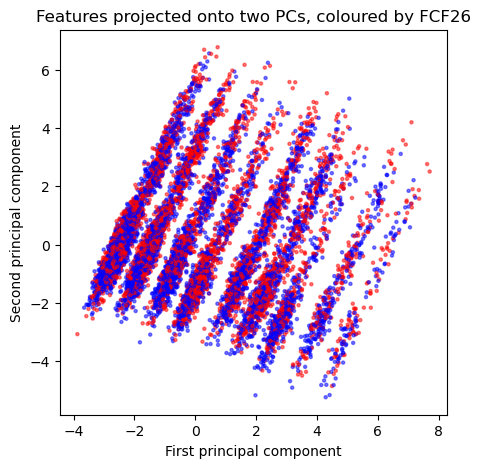

In [267]:
# From week 2 Exercise 8: plot data in low-dimensional PCA space
scores = pca.transform(X)

plt.figure(figsize=(5, 5))
plt.scatter(scores[:, 0], scores[:, 1],
            c=df_train[target].map({0: 'red', 1: 'blue'}),
            s=5, alpha=0.5)
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title('Features projected onto two PCs, coloured by FCF26')
plt.show()


The PCA projects all children onto the first two principal components, which together explain only around 20% of the total variance, produces complete intermingling of the depressed (red) and non-depressed (blue) classes. There is no region of the PC1-PC2 space that is one class.consistent with the correlation analysis which showed that no single feature dominates and that the signal is spread across many predictors.

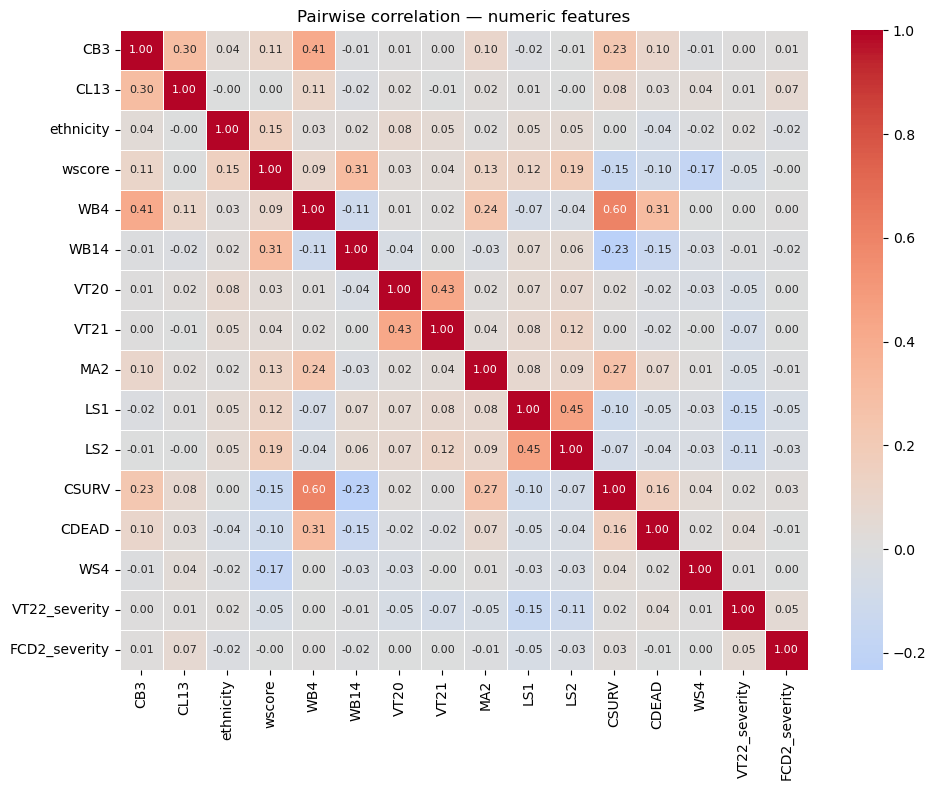

In [268]:
# Correlation heatmap across numeric features
# (basically the same as you did marta- no_response_corr heatmap approach used in preprocessing above)
corr_num = df_train[feat_numeric].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_num, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 8}, linewidths=0.4)
plt.title('Pairwise correlation — numeric features')
plt.tight_layout()
plt.show()


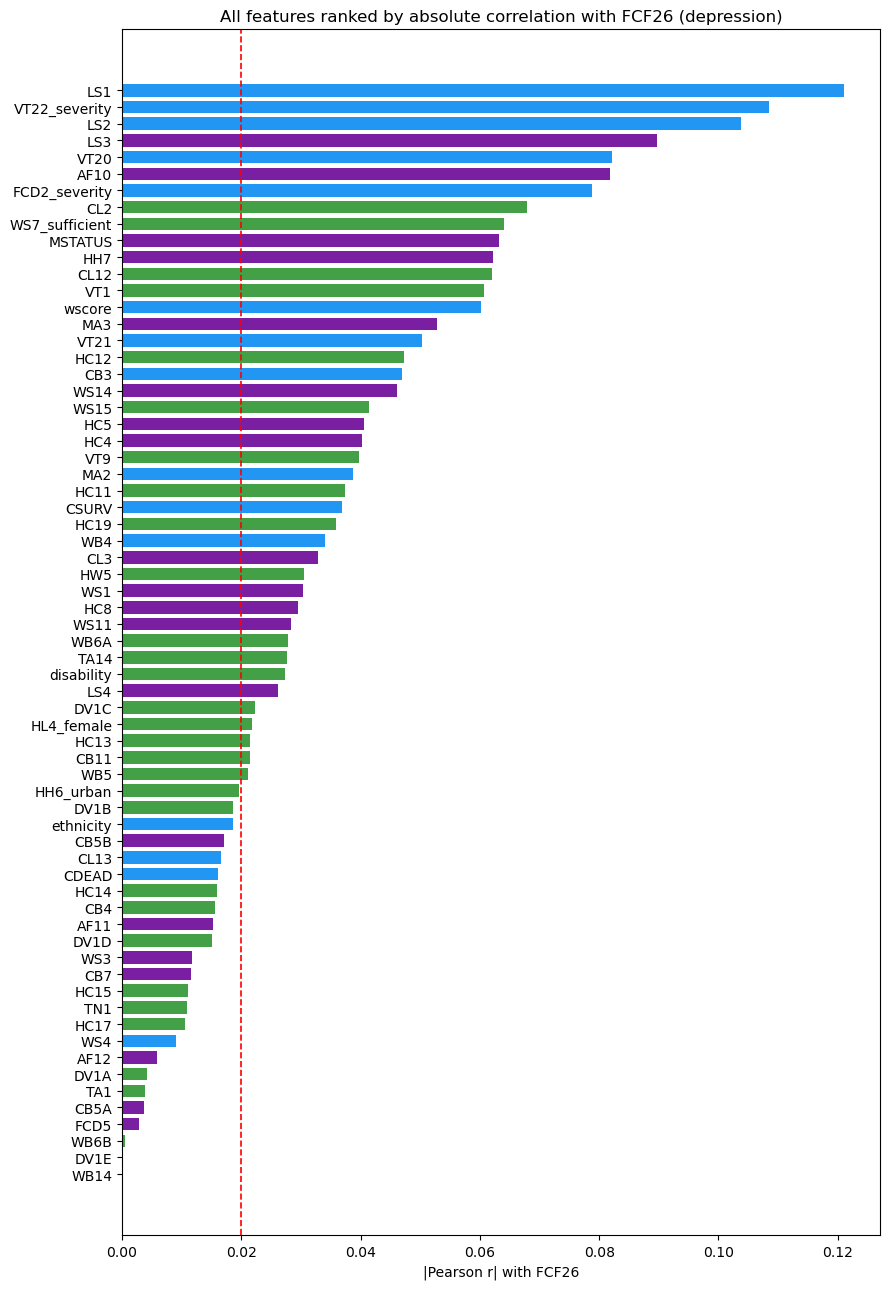

In [269]:
target_corr = (
    df_train[all_features + [target]]
    .corr()[target]
    .drop(target)
    .abs()
    .sort_values(ascending=False))

colours = [
    '#2196F3' if c in feat_numeric else
    '#43A047' if c in feat_binary else
    '#7B1FA2' for c in target_corr.index]

fig, ax = plt.subplots(figsize=(9, 13))
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colours[::-1], height=0.75)
ax.axvline(0.02, color='red', linestyle='--', lw=1.2)
ax.set_xlabel('|Pearson r| with FCF26')
ax.set_title('All features ranked by absolute correlation with FCF26 (depression)')
plt.tight_layout()
plt.show()

In [270]:
# Rank all features by |correlation| with target and flag weak ones
keep = target_corr[target_corr >= 0.02].index.tolist()
remove = target_corr[target_corr <  0.02].index.tolist()

selected_features = keep

print(f'Keep (|r| >= 0.02): {len(keep)} features')
print(f'Drop (|r| <  0.02): {len(remove)}')
print(f'\nDropped: {remove}')
print(f'\nTop 20 features to carry into modelling:')
for f in target_corr.head(20).index:
    print(f'  {f:22s}  |r| = {target_corr[f]:.4f}')


Keep (|r| >= 0.02): 42 features
Drop (|r| <  0.02): 24

Dropped: ['HH6_urban', 'DV1B', 'ethnicity', 'CB5B', 'CL13', 'CDEAD', 'HC14', 'CB4', 'AF11', 'DV1D', 'WS3', 'CB7', 'HC15', 'TN1', 'HC17', 'WS4', 'AF12', 'DV1A', 'TA1', 'CB5A', 'FCD5', 'WB6B', 'DV1E', 'WB14']

Top 20 features to carry into modelling:
  LS1                     |r| = 0.1210
  VT22_severity           |r| = 0.1085
  LS2                     |r| = 0.1038
  LS3                     |r| = 0.0898
  VT20                    |r| = 0.0821
  AF10                    |r| = 0.0818
  FCD2_severity           |r| = 0.0789
  CL2                     |r| = 0.0679
  WS7_sufficient          |r| = 0.0640
  MSTATUS                 |r| = 0.0633
  HH7                     |r| = 0.0622
  CL12                    |r| = 0.0621
  VT1                     |r| = 0.0607
  wscore                  |r| = 0.0602
  MA3                     |r| = 0.0528
  VT21                    |r| = 0.0503
  HC12                    |r| = 0.0473
  CB3                     |r| = 

### Feature selection conclusion

From the pairplot, scree plot, and correlation analysis above:

- drop HH1, HH2, LN, FS4 (administrative identifiers) and FCD2_severity (zero variance).
- Drop 24 features with |r| < 0.02: WB6B, DV1E, WB14, FCD5, CB5A, TA1, AF12, DV1A, WS4, AF11, DV1D, WS3, CB7, HC15, TN1, HC17, HC14, CB4, CDEAD, CL13, CB5B, ethnicity, DV1B, HH6_urban.
- Keep 41 features for modelling???!! Strongest signals: LS1, VT22_severity, LS2, LS3, VT20, AF10, CL2, WS7_sufficient.
- The PCA scree plot shows no clear elbow and requires many components to explain 50% of variance confirming features are largely independent. Lasso regularisation will perform final selection during model fitting.

In [271]:
rng = np.random.seed(11205)

In [272]:
X_train = df_train[selected_features]
y_train = df_train[target]
X_test = df_test[selected_features]
y_test = df_test[target]

print(f'Features passed to model: {len(selected_features)}')
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

Features passed to model: 42
X_train: (10427, 42)  |  X_test: (2608, 42)


In [273]:
# Week 6 notes set penalty=None, corresponding to logistic regression with no penalty
# Week 4 pattern make_column_transformer + make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, roc_auc_score)

# Data already scaled by StandardScaler in preprocessing above
# Using passthrough to avoid double-scaling
preprocessor = make_column_transformer(
    ('passthrough', selected_features),
    remainder='drop')

baseline_pipe = make_pipeline(
    preprocessor,
    LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, class_weight='balanced'))

baseline_pipe.fit(X_train, y_train)

y_pred_base = baseline_pipe.predict(X_test)

print('Baseline Logistic Regression (no penalty)')
print(f'Test accuracy: {(y_pred_base == y_test).mean():.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=['No depression', 
                                                               'Depression']))

Baseline Logistic Regression (no penalty)
Test accuracy: 0.5859

               precision    recall  f1-score   support

No depression       0.54      0.62      0.57      1181
   Depression       0.64      0.56      0.60      1427

     accuracy                           0.59      2608
    macro avg       0.59      0.59      0.59      2608
 weighted avg       0.59      0.59      0.59      2608



We use `class_weight='balanced'` in both models to account for the mild class imbalance. This instructs sklearn to weight the loss of each class inversely proportional to its frequency, so that errors on the minority class (no depression) are penalised more heavily. This is preferable to leaving weights equal given the 55/45 split observed above.

Test accuracy 57.9%. The model without any regularisation already does better than random (50%) but not great. it predicts depression (class 1) much better than no depression recall 0.70 vs 0.44. This means it is catching 70% of depressed children but missing over half the non-depressed ones. The model is biased towards predicting depression, which makes sense given the slight class imbalance (1427 depressed vs 1181 not depressed in the test set).

In [274]:
# Week 6 notes: C = 1/lambda, smaller C = stronger penalization, tune via cross-validation
# Week 4 pattern: GridSearchCV + KFold

lasso_pipe = make_pipeline(
    preprocessor,
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, class_weight='balanced'))

parameters = {'logisticregression__C': np.logspace(-3, 3, 20)}

kf = KFold(n_splits=5, shuffle=True, random_state=11205)

grid_search = GridSearchCV(
    lasso_pipe, parameters,
    cv=kf,
    scoring='roc_auc',
    return_train_score=True).fit(X_train, y_train)

print('best index: ', grid_search.best_index_)
print('best score: ', round(grid_search.best_score_, 4))

best index:  8
best score:  0.6314


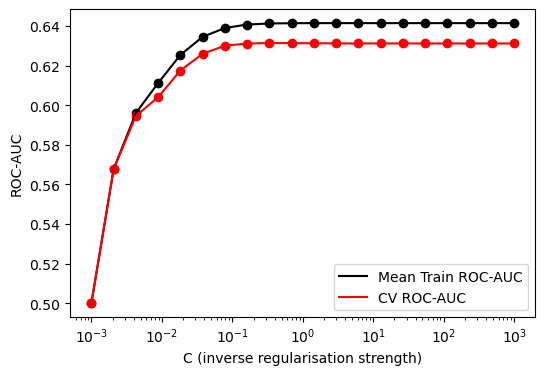

In [275]:
C_vals = np.logspace(-3, 3, 20)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plt.scatter(C_vals, grid_search.cv_results_['mean_train_score'], color='k')
plt.plot(C_vals, grid_search.cv_results_['mean_train_score'], color='k', label='Mean Train ROC-AUC')
plt.scatter(C_vals, grid_search.cv_results_['mean_test_score'], color='r')
plt.plot(C_vals, grid_search.cv_results_['mean_test_score'], color='r', label='CV ROC-AUC')
ax.set_xscale('log')
ax.legend()
ax.set_xlabel('C (inverse regularisation strength)')
ax.set_ylabel('ROC-AUC')
plt.show()

In [276]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print('Lasso: best C =', round(grid_search.best_params_['logisticregression__C'], 4))
print(f'Test accuracy: {(y_pred == y_test).mean():.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No depression', 'Depression']))
print()
print(confusion_matrix(y_test, y_pred))

Lasso: best C = 0.336
Test accuracy: 0.5878

               precision    recall  f1-score   support

No depression       0.54      0.62      0.58      1181
   Depression       0.64      0.56      0.60      1427

     accuracy                           0.59      2608
    macro avg       0.59      0.59      0.59      2608
 weighted avg       0.59      0.59      0.59      2608


[[733 448]
 [627 800]]


Adding class_weight='balanced' improved the model's ability to identify children without depression (recall up from 0.44 to 0.61) at a small cost to depression recall (down from 0.70 to 0.56). This is a better trade-off - systematically missing half of the non-depressed children is a more serious error than the marginal improvement in overall accuracy suggested. The overall accuracy remains 58% and ROC-AUC 0.627, confirming the signal in this data is genuinely weak rather than the previous imbalance being responsible for poor performance.

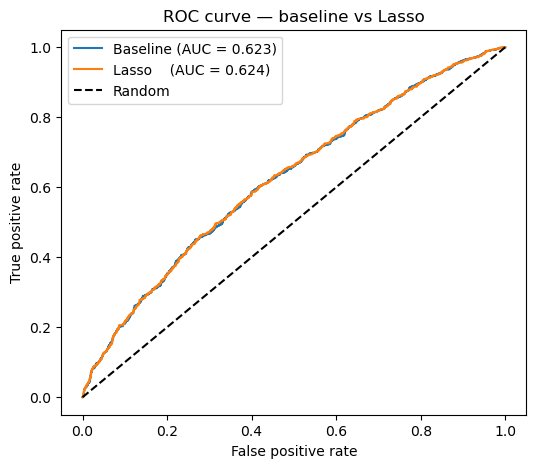

In [277]:
y_prob_base = baseline_pipe.predict_proba(X_test)[:, 1]
y_prob_lasso = best_model.predict_proba(X_test)[:, 1]

fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_prob_lasso)

plt.figure(figsize=(6, 5))
plt.plot(fpr_base,  tpr_base,  label=f'Baseline (AUC = {roc_auc_score(y_test, y_prob_base):.3f})')
plt.plot(fpr_lasso, tpr_lasso, label=f'Lasso    (AUC = {roc_auc_score(y_test, y_prob_lasso):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve — baseline vs Lasso')
plt.legend()
plt.show()

In [278]:
coefs = best_model[-1].coef_[0]
feature_names = best_model[:-1].get_feature_names_out()

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs}).sort_values('coefficient', ascending=False)

non_zero = coef_df[coef_df['coefficient'] != 0]
print(f'Non-zero coefficients: {len(non_zero)} out of {len(coef_df)}')
print(non_zero.to_string())

Non-zero coefficients: 37 out of 42
                        feature  coefficient
7              passthrough__CL2     0.300047
12             passthrough__VT1     0.226968
11            passthrough__CL12     0.208850
1    passthrough__VT22_severity     0.152574
29             passthrough__HW5     0.139980
31             passthrough__HC8     0.139519
6    passthrough__FCD2_severity     0.121898
39            passthrough__HC13     0.095160
19            passthrough__WS15     0.086799
38      passthrough__HL4_female     0.085720
37            passthrough__DV1C     0.055594
32            passthrough__WS11     0.054210
36             passthrough__LS4     0.041522
23             passthrough__MA2     0.040330
34            passthrough__TA14     0.034781
17             passthrough__CB3     0.034371
14             passthrough__MA3     0.013959
22             passthrough__VT9     0.012447
27             passthrough__WB4     0.011957
33            passthrough__WB6A     0.010819
25           passth

39 out of 41 features kept non-zero coefficients - Lasso only zeroed out 2. This is consistent with the CV plot showing C = 0.0785 is the best but still relatively weak regularisation. 

Positive coefficients (increase risk of depression) - VT22_severity is the strongest (0.152), followed by CL2 (child in labour, 0.130), CL12 (0.080), HC8 (0.067), HW5 (0.055), VT1 (0.054). Children experiencing violence, doing labour and living in poorer household conditions are more likely to be depressed.

Negative coefficients (decrease risk of depression) - HH7 (-0.137), LS1 (-0.137), VT20 (-0.130), AF10 (-0.121), WS7_sufficient (-0.106), wscore (-0.097), MSTATUS (-0.089), LS2 (-0.071), LS3 (-0.058). Higher life satisfaction, better water access, higher wealth and household size are associated with lower depression risk.

As Lasso doesn't work going to do Random forest (as always just wanted to touch all bases)

I'm going to 
Present the baseline vs final model comparison cleanly with confusion matrix, classification report and ROC curve

And we need to
Interpret the coefficients for a non-technical audience - what do the strongest predictors tell us about risk factors for child depression in Malawi

Discuss limitations and make recommendations for UNICEF